# Case Study — Stunnerz Skateboards

This notebook adapts a Bayesian Media Mix Modeling (MMM) workflow to the **Stunnerz Skateboards** dataset.

**Goals**
- clean and aggregate the raw media data to a weekly modeling table,
- evaluate data quality and likely modeling risks,
- fit a Bayesian MMM,
- interpret channel contribution, saturation, ROAS, and predictive performance,
- answer the client-facing case questions using the model outputs.


## Prepare Notebook

This section installs the modeling stack and sets a reproducible environment.

**Why weekly?**  
The source file is daily, but we model the data at the **weekly** level because weekly MMMs are usually more stable and less sensitive to day-level noise.


In [1]:
# Dependencies are pinned in requirements.txt:
#   pip install -r requirements.txt
# In Colab, uncomment the line below.
# %pip -q install -r requirements.txt


In [2]:
import warnings
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import xarray as xr
from pymc_extras.prior import Prior
from pymc_marketing.metrics import crps
from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.multidimensional import MMM

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 110
%config InlineBackend.figure_format = "retina"


In [5]:
seed: int = sum(map(ord, "stunnerz_mmm"))
rng = np.random.default_rng(seed=seed)


## Load and Prepare the Data

In [6]:
# Read the raw CSV, validate the core fields, and aggregate to weekly level.
# We drop zero-sales daily rows before aggregation because the tail of the file
# appears incomplete and can distort both EDA and model fitting.

data_path = Path("stunnerz_skateboards_simulated_data.csv")
assert data_path.exists(), f"Could not find {data_path.resolve()}"

raw_df = pd.read_csv(data_path)
raw_df["date"] = pd.to_datetime(raw_df["date"])
raw_df = raw_df.sort_values("date").reset_index(drop=True)

required_columns = {"date", "total_sales", "promo", "weekday"}
missing_required = required_columns - set(raw_df.columns)
assert not missing_required, f"Missing required columns: {missing_required}"

sales_col = "total_sales"
channel_columns = [
    col for col in raw_df.columns
    if col not in ["date", sales_col, "promo", "weekday"]
]

raw_df = raw_df.loc[raw_df[sales_col] > 0].copy()
raw_df["week_start"] = raw_df["date"].dt.to_period("W-MON").apply(lambda r: r.start_time)

promo_dummies = pd.get_dummies(raw_df["promo"], prefix="promo", drop_first=True, dtype=float)

weekly_df = pd.concat([raw_df[["week_start", sales_col, *channel_columns]], promo_dummies], axis=1)
weekly_df = weekly_df.groupby("week_start", as_index=False).sum()
weekly_df = weekly_df.rename(columns={"week_start": "date", sales_col: "sales"})

control_columns = [col for col in weekly_df.columns if col.startswith("promo_")]
date_column = "date"
target_column = "sales"
data_df = weekly_df.copy()

display(data_df.head())
print(f"Rows after cleaning and weekly aggregation: {len(data_df)}")
print(f"Channel columns ({len(channel_columns)}): {channel_columns}")
print(f"Control columns ({len(control_columns)}): {control_columns}")


,date,sales,google_display,google_search_brand,google_search_nob,facebook_pr,facebook_rt,google_discovery,bing_search_brand,bing_shopping_feed,pinterest_viz,pinterest_pr,pinterest_rt,google_pmax,promo_big_sale,promo_holiday_sale,promo_other_sale
0,2020-12-29,172044.099911,150.346286,2784.842134,3186.215936,2194.696082,2366.499242,49.677672,229.828934,548.558301,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2021-01-05,298506.120271,450.544376,3885.423596,7205.782748,6898.907725,8084.843556,180.393920,462.889328,1042.872831,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2021-01-12,380721.851030,964.310919,4508.326834,8968.786105,8399.310228,9445.802856,160.714263,541.229078,1370.814028,0.0,0.0,0.0,0.0,0.0,0.0,3.0
3,2021-01-19,291149.101965,937.312306,4455.413805,6845.423462,5545.837872,8096.384798,141.622572,475.698354,1146.788584,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2021-01-26,436322.395673,1494.447898,4652.429944,6151.119754,6725.371094,8776.031266,420.840742,590.222113,1189.505887,0.0,0.0,0.0,0.0,6.0,0.0,1.0


Rows after cleaning and weekly aggregation: 194
Channel columns (12): ['google_display', 'google_search_brand', 'google_search_nob', 'facebook_pr', 'facebook_rt', 'google_discovery', 'bing_search_brand', 'bing_shopping_feed', 'pinterest_viz', 'pinterest_pr', 'pinterest_rt', 'google_pmax']
Control columns (3): ['promo_big_sale', 'promo_holiday_sale', 'promo_other_sale']


## Exploratory Data Analysis

In [7]:
# Confirm the usable weekly modeling window after cleaning.
print(f"Weekly history available for modeling: {len(data_df)} weeks")
print(f"Date range: {data_df[date_column].min().date()} to {data_df[date_column].max().date()}")


Weekly history available for modeling: 194 weeks
Date range: 2020-12-29 to 2024-09-10


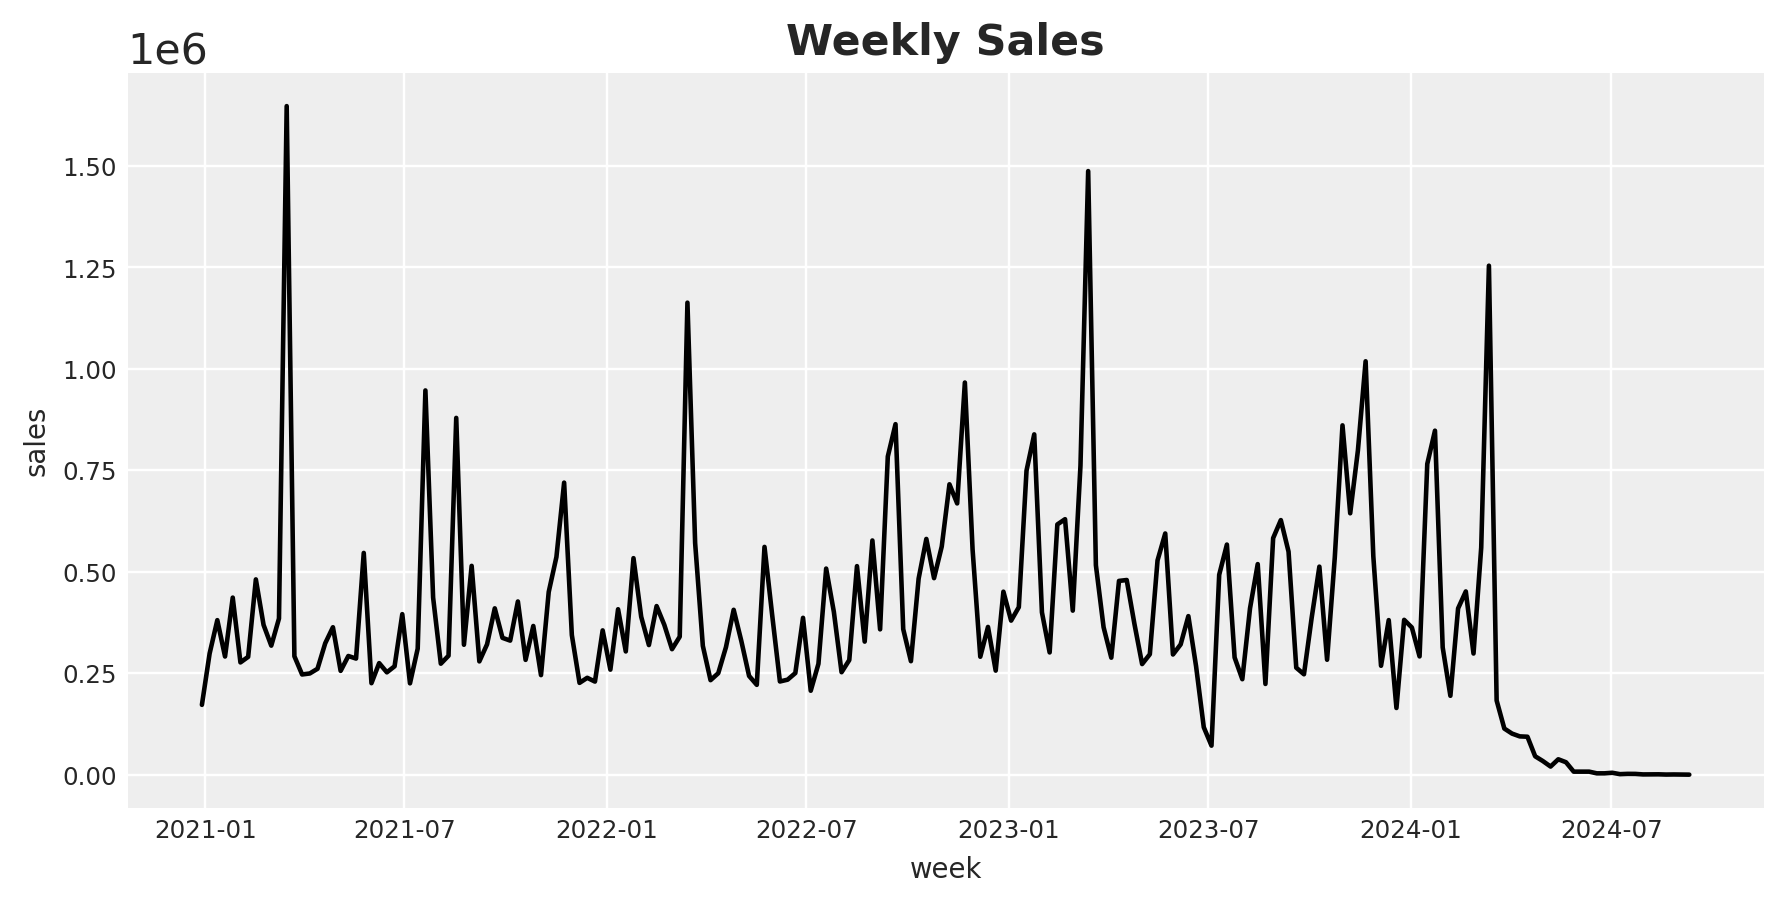

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.lineplot(data=data_df, x=date_column, y=target_column, color="black", ax=ax)

ax.set_xlabel("week", fontsize=9)
ax.set_ylabel("sales", fontsize=9)
ax.set_title("Weekly Sales", fontsize=14, fontweight="bold")

ax.tick_params(axis='both', labelsize=8)

plt.show()

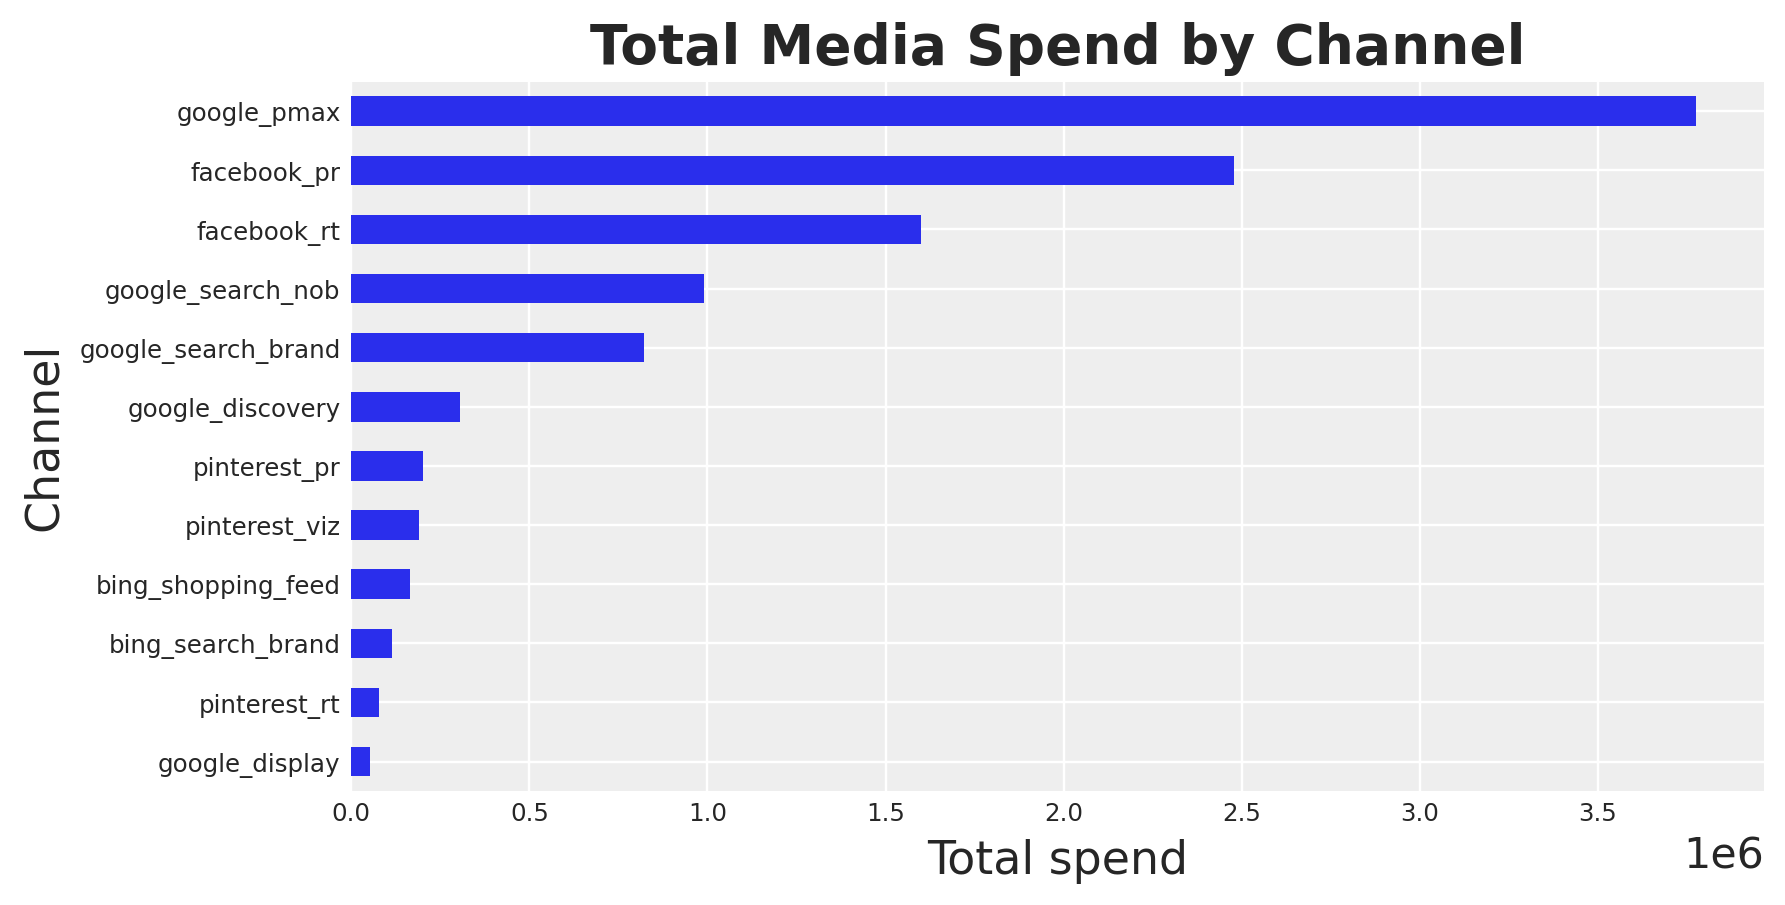

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
(
    data_df.melt(value_vars=channel_columns, var_name="channel", value_name="spend")
    .groupby("channel", as_index=False)["spend"]
    .sum()
    .sort_values(by="spend")
    .plot.barh(x="channel", y="spend", legend=False, ax=ax)
)

ax.set(xlabel="Total spend", ylabel="Channel")
ax.set_title("Total Media Spend by Channel", fontsize=18, fontweight="bold")
ax.tick_params(axis='both', labelsize=8)
plt.show()

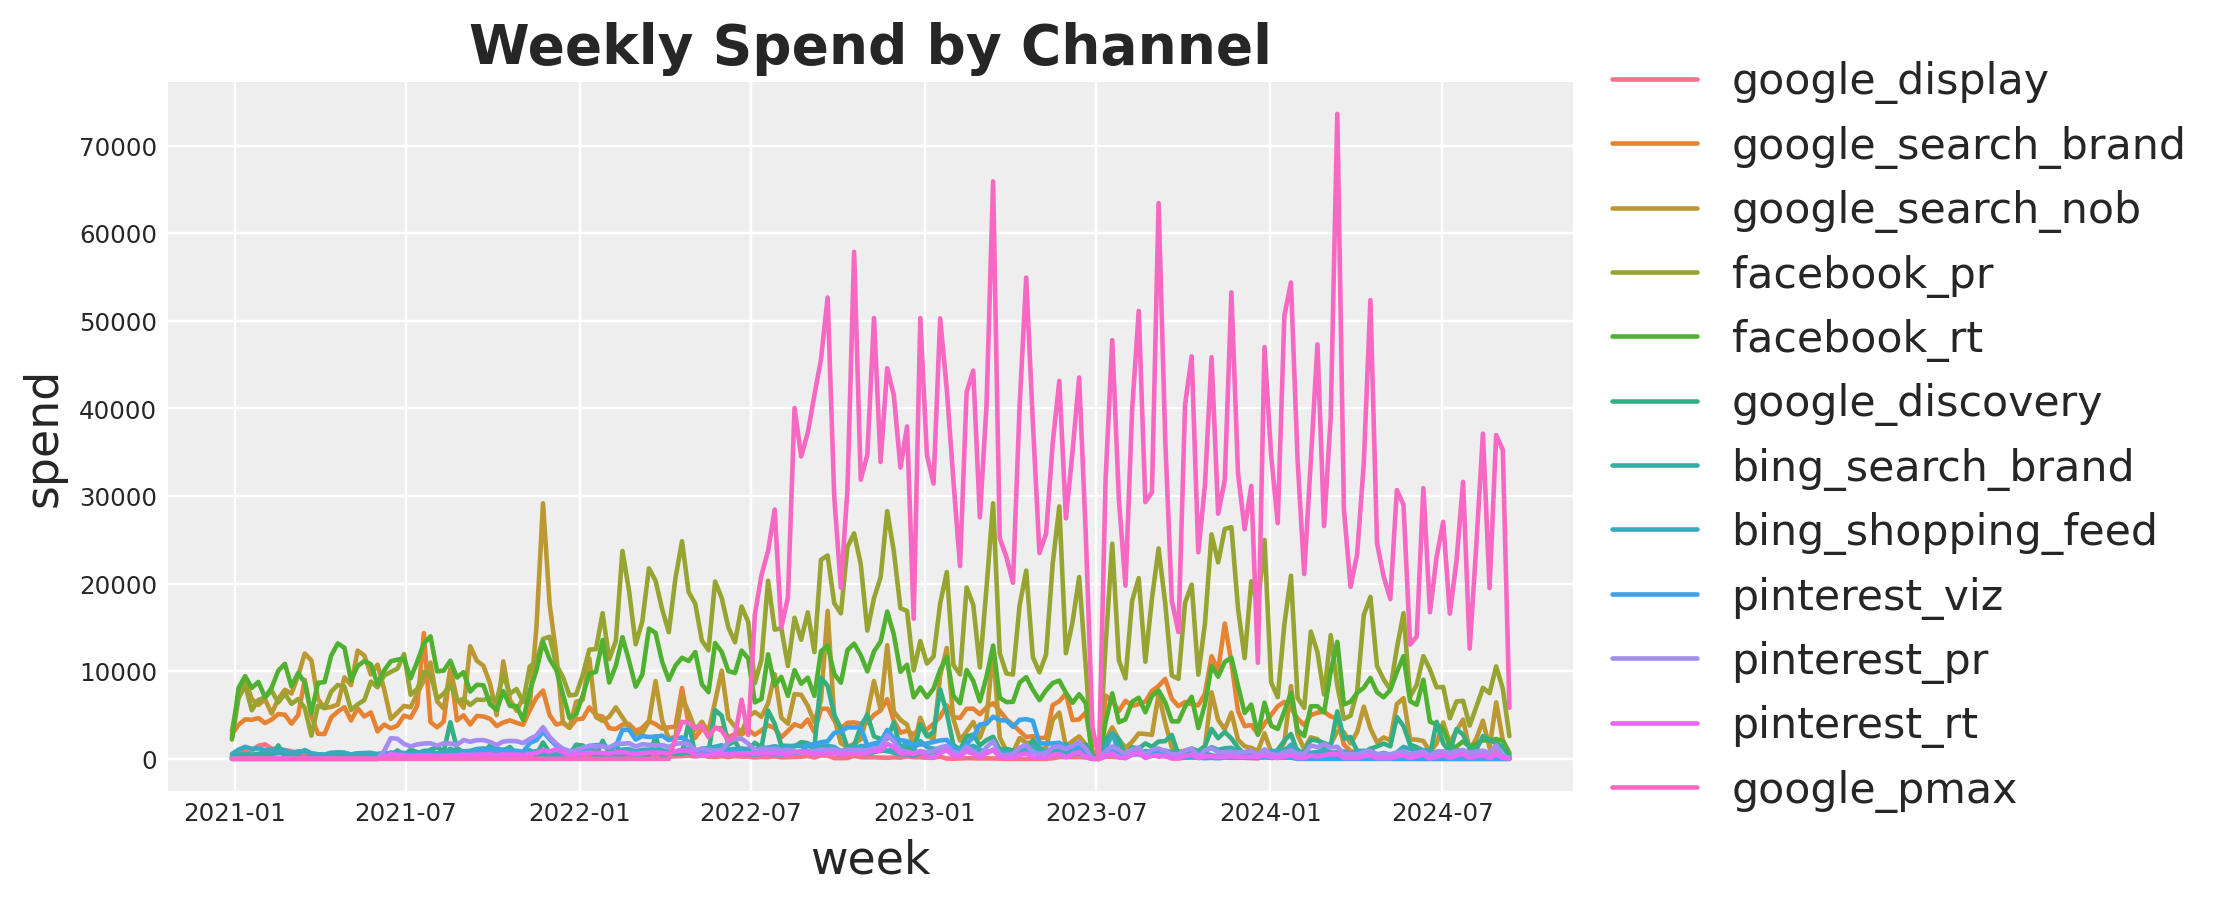

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_df = data_df.melt(id_vars=date_column, value_vars=channel_columns, var_name="channel", value_name="spend")
sns.lineplot(data=plot_df, x=date_column, y="spend", hue="channel", ax=ax)
ax.set(xlabel="week", ylabel="spend")
ax.set_title("Weekly Spend by Channel", fontsize=18, fontweight="bold")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.tick_params(axis='both', labelsize=8)
plt.show()

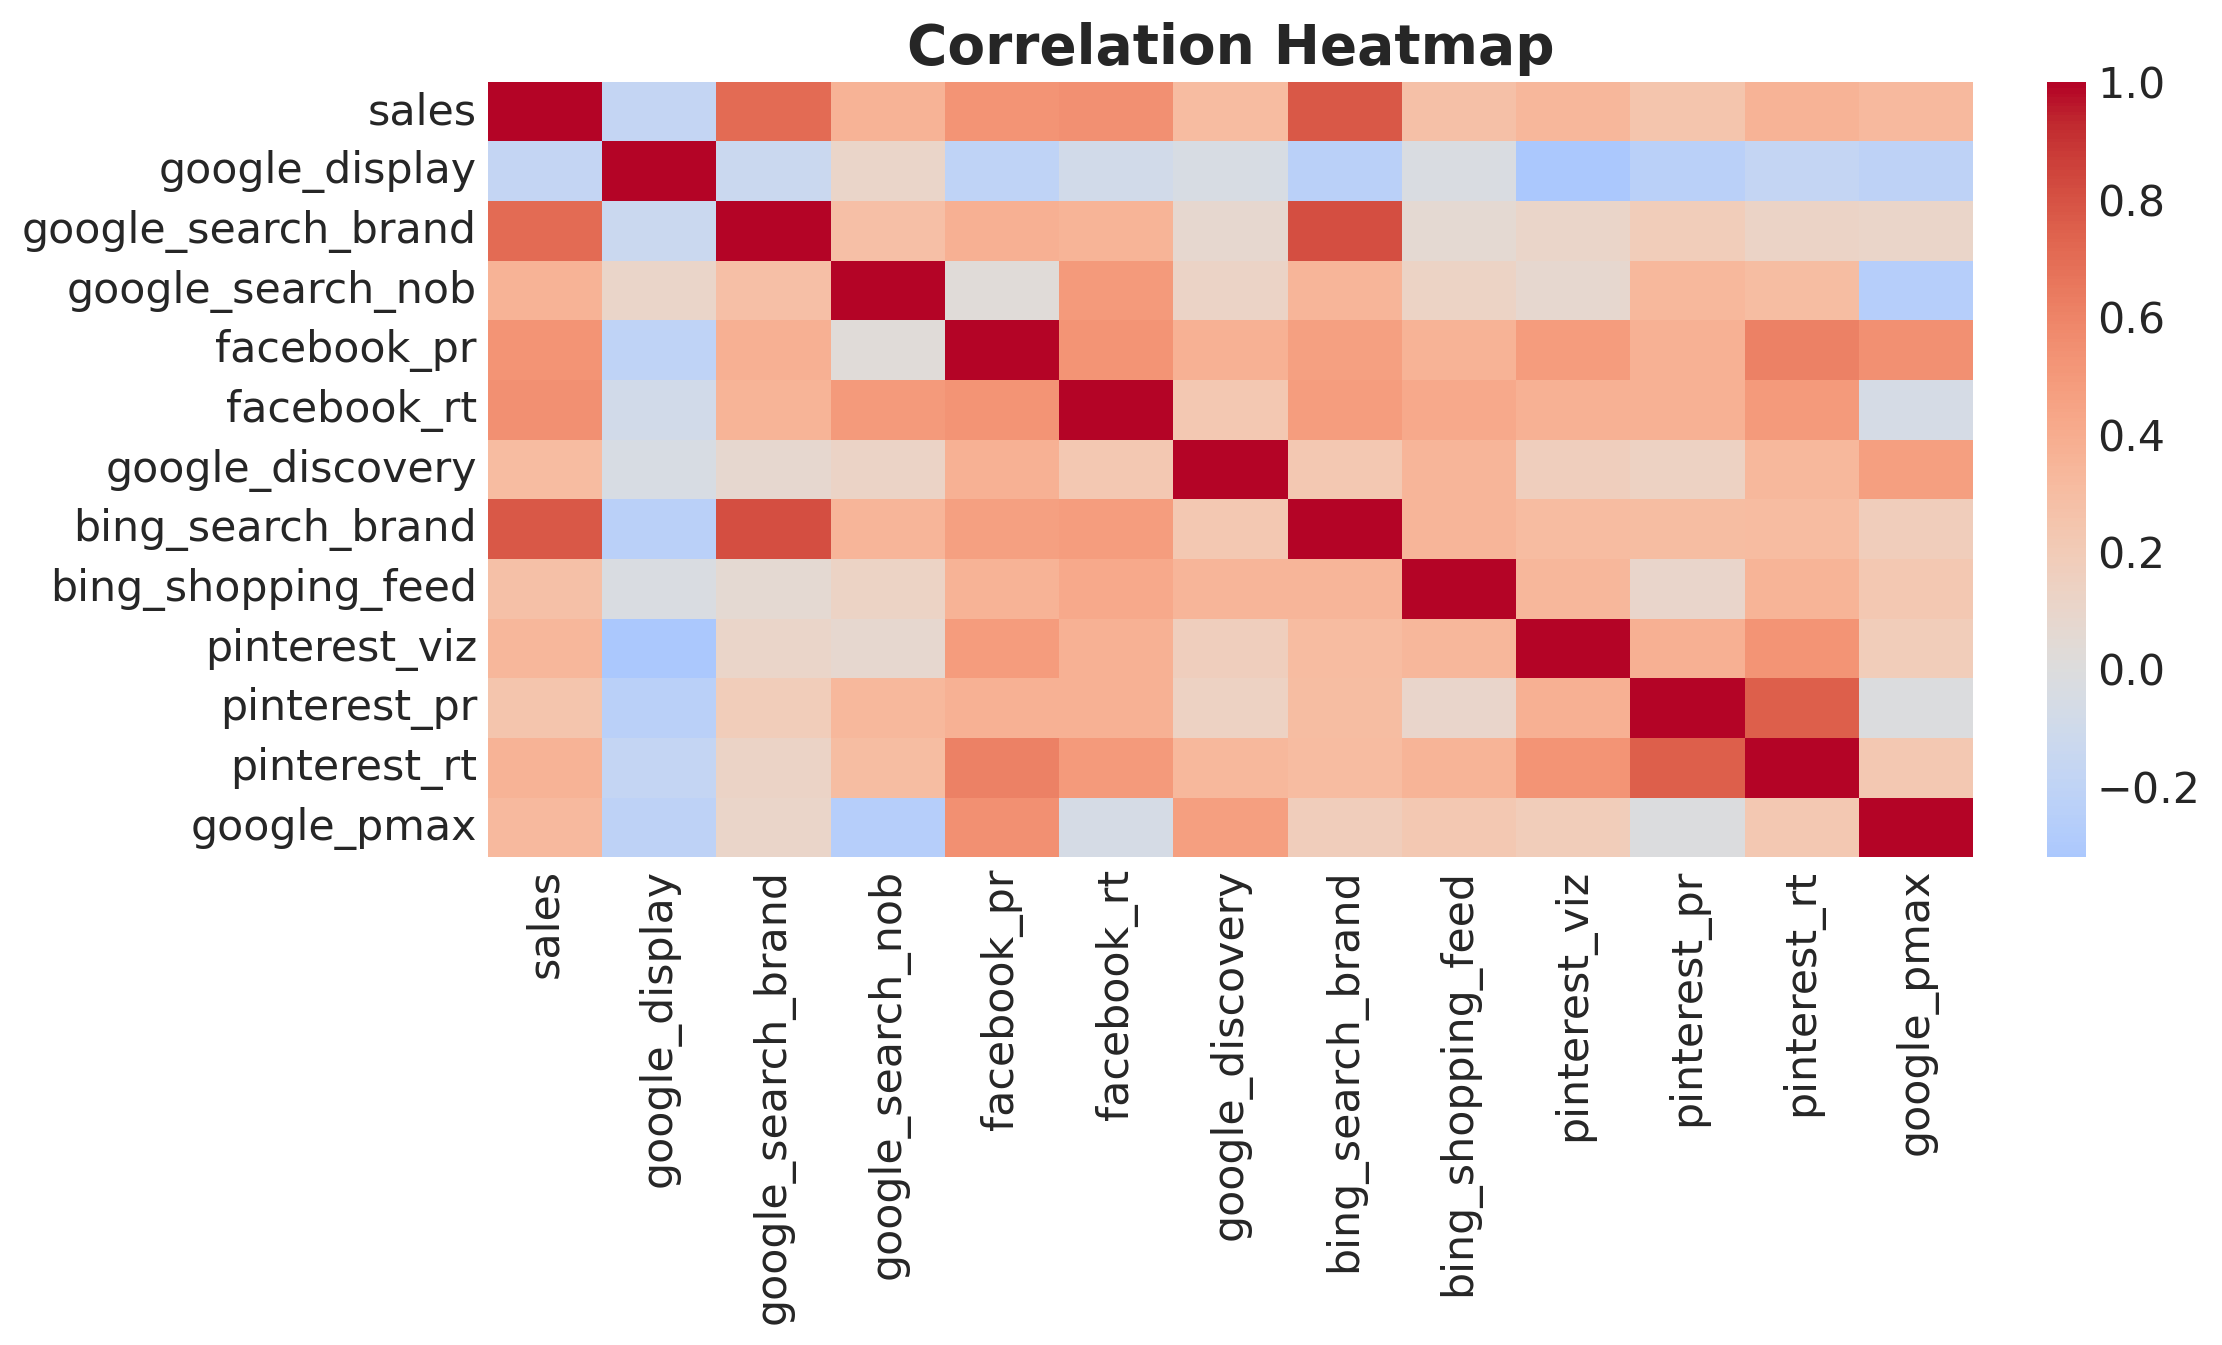

In [11]:
# Correlation is not causation, but it is still useful for spotting overlap and data quality issues.
corr_df = data_df[[target_column, *channel_columns]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(corr_df, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap", fontsize=18, fontweight="bold")
plt.show()


In [12]:
sales_corr = (
    data_df[[target_column, *channel_columns]]
    .corr(numeric_only=True)[target_column]
    .drop(target_column)
    .sort_values(ascending=False)
)

corr_summary_df = sales_corr.rename("corr_with_sales").reset_index().rename(columns={"index": "channel"})
display(corr_summary_df.style.format({"corr_with_sales": "{:.3f}"}))

strong_positive = corr_summary_df[corr_summary_df["corr_with_sales"] >= 0.50]["channel"].tolist()
moderate_positive = corr_summary_df[
    (corr_summary_df["corr_with_sales"] >= 0.25) & (corr_summary_df["corr_with_sales"] < 0.50)
]["channel"].tolist()
negative_corr = corr_summary_df[corr_summary_df["corr_with_sales"] < 0]["channel"].tolist()

print("Strong positive correlation with sales:", strong_positive)
print("Moderate positive correlation with sales:", moderate_positive)
print("Negative correlation with sales:", negative_corr)

,channel,corr_with_sales
0,bing_search_brand,0.776
1,google_search_brand,0.707
2,facebook_rt,0.544
3,facebook_pr,0.527
4,pinterest_rt,0.361
5,google_search_nob,0.360
6,pinterest_viz,0.337
7,google_pmax,0.324
8,google_discovery,0.310
9,bing_shopping_feed,0.273


Strong positive correlation with sales: ['bing_search_brand', 'google_search_brand', 'facebook_rt', 'facebook_pr']
Moderate positive correlation with sales: ['pinterest_rt', 'google_search_nob', 'pinterest_viz', 'google_pmax', 'google_discovery', 'bing_shopping_feed', 'pinterest_pr']
Negative correlation with sales: ['google_display']


In [13]:
# Further Diagnostics

# 1) Sparse channels: a high share of zero-spend weeks makes channel attribution harder.
# 2) Highly correlated channels: these pairs can create multicollinearity pressure in the MMM.
sparse_channel_df = (
    (data_df[channel_columns] == 0)
    .mean()
    .sort_values(ascending=False)
    .rename("share_of_zero_spend_weeks")
    .reset_index()
    .rename(columns={"index": "channel"})
)

high_corr_pairs = []
channel_corr = data_df[channel_columns].corr().abs()
for i, ch1 in enumerate(channel_corr.columns):
    for ch2 in channel_corr.columns[i + 1:]:
        high_corr_pairs.append((ch1, ch2, channel_corr.loc[ch1, ch2]))

high_corr_pairs_df = (
    pd.DataFrame(high_corr_pairs, columns=["channel_1", "channel_2", "abs_corr"])
    .sort_values("abs_corr", ascending=False)
    .reset_index(drop=True)
)

display(high_corr_pairs_df.head(10).style.format({"abs_corr": "{:.3f}"}))


,channel_1,channel_2,abs_corr
0,google_search_brand,bing_search_brand,0.815
1,pinterest_pr,pinterest_rt,0.756
2,facebook_pr,pinterest_rt,0.616
3,facebook_pr,google_pmax,0.546
4,pinterest_viz,pinterest_rt,0.528
5,facebook_pr,facebook_rt,0.527
6,facebook_rt,pinterest_rt,0.495
7,google_search_nob,facebook_rt,0.492
8,facebook_pr,pinterest_viz,0.485
9,facebook_rt,bing_search_brand,0.481


In [14]:
print("Channels with the most zero-spend weeks")
display(sparse_channel_df.style.format({"share_of_zero_spend_weeks": "{:.1%}"}))


Channels with the most zero-spend weeks


,channel,share_of_zero_spend_weeks
0,google_pmax,35.1%
1,pinterest_viz,29.4%
2,pinterest_pr,12.4%
3,pinterest_rt,12.4%
4,google_display,4.1%
5,bing_search_brand,2.6%
6,facebook_pr,1.0%
7,facebook_rt,1.0%
8,bing_shopping_feed,1.0%
9,google_search_brand,0.5%


The next section translates the EDA into **client-facing implications**.  
The focus is not just what the charts show, but what those patterns mean for data quality, model reliability, and future measurement strategy.


## Data Assessment and Modeling Considerations

### Are there shortcomings in this data?

- The dataset contains the essentials for a first-pass MMM — **channel spend, sales, date, and promotion flags** — but it is still missing several important business drivers such as **price, discount depth, inventory availability, and competitive activity**.
- Some channels are sparse. In particular, **google_pmax**, **pinterest_viz**, **pinterest_pr**, and **pinterest_rt** have a meaningful share of zero-spend weeks, which reduces the amount of variation available for estimating their true effect.
- A few channels appear to have been introduced or scaled later in the history, so the model has fewer observations from which to learn their contribution.
- The dataset spans roughly **194 weekly observations**, which is usable for MMM, but the consistency of signal varies a lot by channel.


### Does anything appear suspicious or problematic?

- Weekly sales are **highly volatile**, with several sharp spikes that look more like event-driven demand than smooth baseline behavior.
- The final portion of the original history shows a **collapse toward near-zero sales**, which strongly suggests incomplete data rather than a real business decline. This is why zero-sales tail periods were removed before modeling.
- Several channels move together strongly enough to create **multicollinearity risk**. The clearest examples are:
  - **google_search_brand ↔ bing_search_brand (0.815)**
  - **pinterest_pr ↔ pinterest_rt (0.756)**
  - **facebook_pr ↔ pinterest_rt (0.616)**
  - **facebook_pr ↔ google_pmax (0.546)**
  - **facebook_pr ↔ facebook_rt (0.527)**
- **google_display** has a slightly negative simple correlation with sales. That does **not** automatically mean the channel hurts revenue; it may reflect upper-funnel timing, lagged effects, overlap with other channels, or measurement noise.


### What could be added that might improve model performance?

- **Pricing and richer promotion detail** would likely help the most. A binary promo flag is useful, but discount depth, promotion type, and promotion duration would separate media effects from merchandising effects more cleanly.
- **Inventory and stock availability** would reduce the risk of treating stock-related demand suppression as a media failure.
- **Digital funnel metrics** such as sessions, clicks, add-to-carts, or conversion rate could help explain how spend translates into customer behavior before sales happen.
- A **longer stable history** would improve estimation of seasonality, lag, and channel saturation.
- If sparse channels remain sparse, grouping them into broader channel families may improve stability and interpretability.


# Modeling

## Train/Test Split

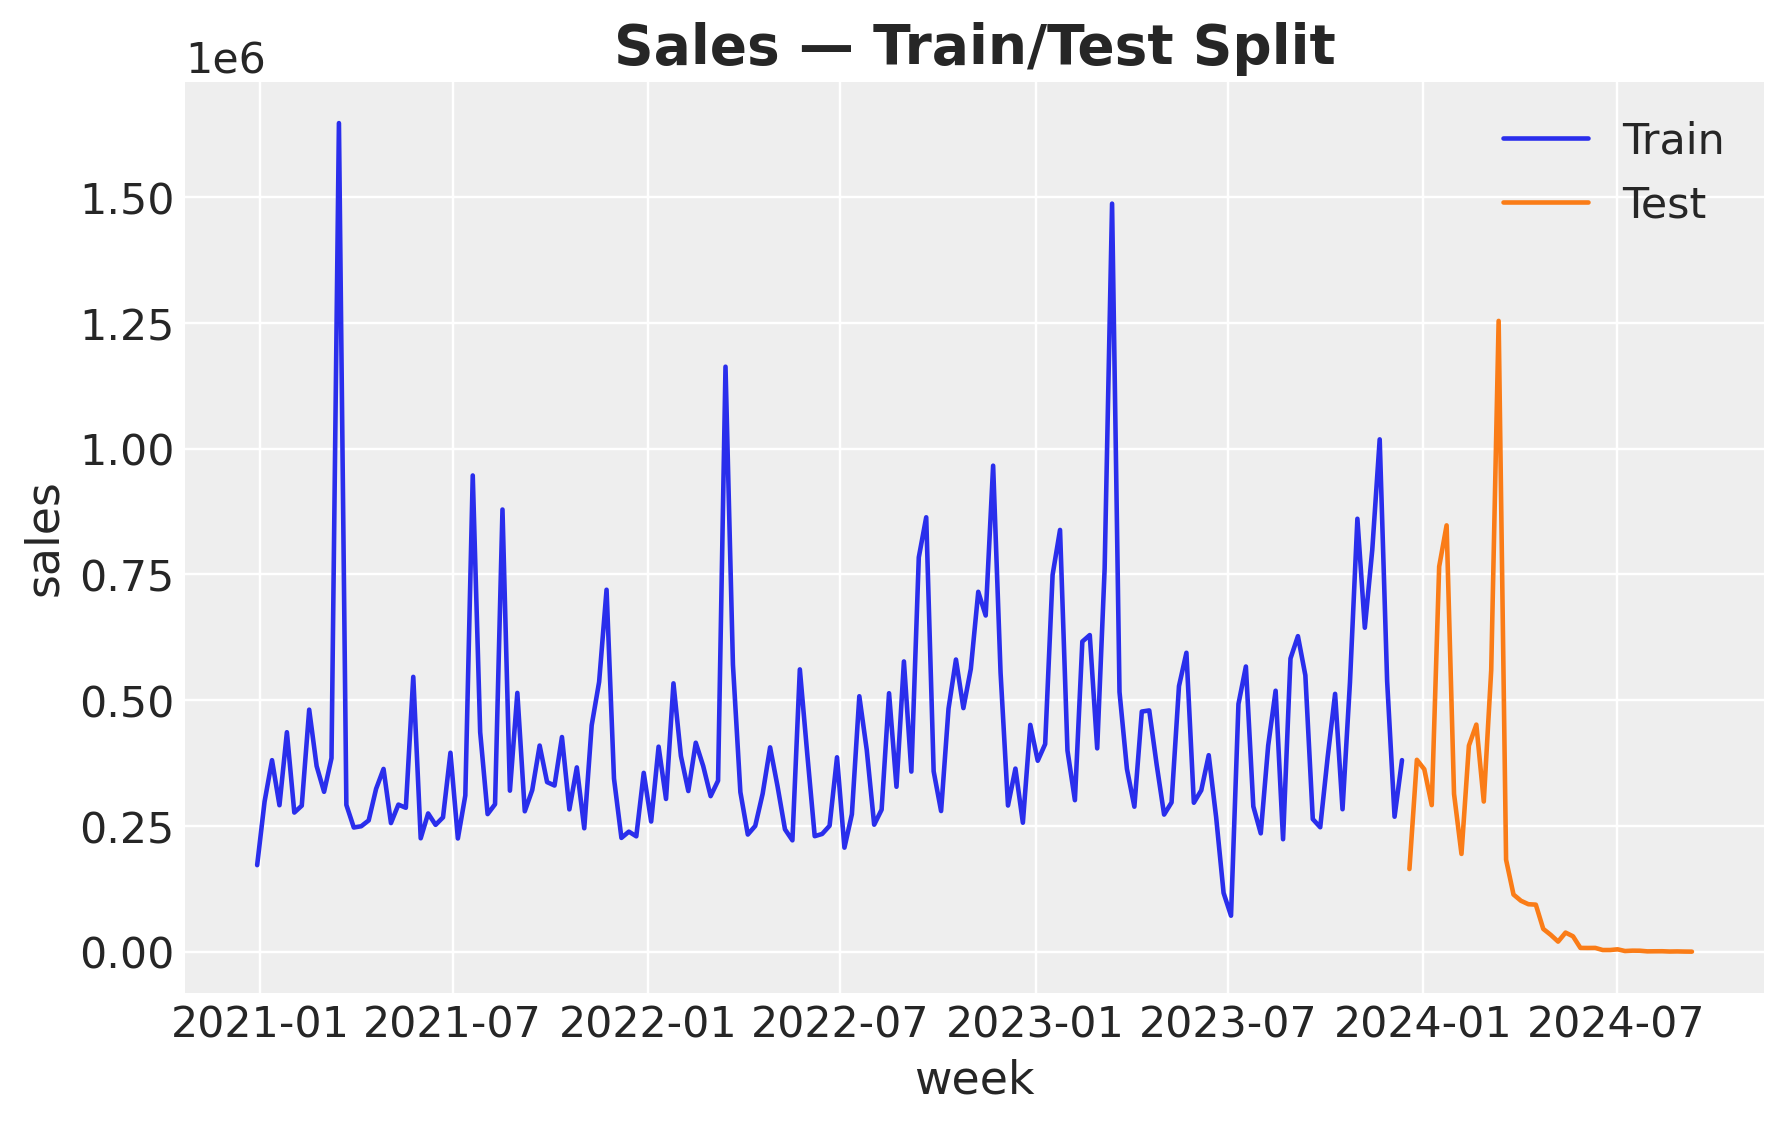

In [15]:
# Preserve chronology. For time-series work, random splits would leak future information.
split_idx = int(len(data_df) * 0.80)
train_df = data_df.iloc[:split_idx].copy()
test_df = data_df.iloc[split_idx:].copy()
train_test_split_date = test_df[date_column].min()

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=train_df, x=date_column, y=target_column, color="C0", label="Train", ax=ax)
sns.lineplot(data=test_df, x=date_column, y=target_column, color="C1", label="Test", ax=ax)
ax.set(xlabel="week", ylabel="sales")
ax.set_title("Sales — Train/Test Split", fontsize=18, fontweight="bold")
plt.show()


In [16]:
# Separate features from the target.
X_train = train_df.drop(columns=[target_column])
X_test = test_df.drop(columns=[target_column])

y_train = train_df[target_column]
y_test = test_df[target_column]

print(f"Training set: {len(train_df)} weekly observations")
print(f"Test set: {len(test_df)} weekly observations")
print(f"Train period: {train_df[date_column].min().date()} to {train_df[date_column].max().date()}")
print(f"Test period: {test_df[date_column].min().date()} to {test_df[date_column].max().date()}")


Training set: 155 weekly observations
Test set: 39 weekly observations
Train period: 2020-12-29 to 2023-12-12
Test period: 2023-12-19 to 2024-09-10


### Train/Test Split Summary

- The split is **chronological**, which is the correct approach for time-series validation.
- The training window contains the bulk of the historical variation needed for model fitting.
- The test window gives a true **forward-looking check** of predictive performance.
- Because the source file appears incomplete at the end, test-set performance should be interpreted with some caution.


## Model Specification

In [ ]:
# Use spend shares to set weakly informative channel priors.
# This does not force high-spend channels to be "better"; it only gives them
# proportionally more room to explain sales if the data supports it.
# Shares are computed in channel_columns order so each prior lines up with its
# channel by name. (A groupby would sort alphabetically; newer PyMC-Marketing
# releases keep column order, which would silently misassign priors.)
channel_spend_totals = X_train[channel_columns].sum()
spend_shares = (channel_spend_totals / channel_spend_totals.sum()).to_numpy()

prior_sigma = np.clip(spend_shares, 0.01, None)
pd.Series(spend_shares, index=channel_columns).round(3)

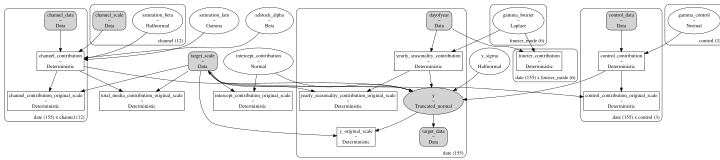

In [18]:
# Build a simple Bayesian MMM:
# - geometric adstock captures carryover,
# - logistic saturation captures diminishing returns,
# - Fourier terms capture recurring annual seasonality.
model_config = {
    "intercept": Prior("Normal", mu=0.2, sigma=0.1),
    "saturation_beta": Prior("HalfNormal", sigma=prior_sigma, dims="channel"),
    "gamma_control": Prior("Normal", mu=0, sigma=1, dims="control"),
    "gamma_fourier": Prior("Laplace", mu=0, b=1, dims="fourier_mode"),
    "likelihood": Prior("TruncatedNormal", lower=0, sigma=Prior("HalfNormal", sigma=1)),
}

mmm = MMM(
    model_config=model_config,
    target_column=target_column,
    date_column=date_column,
    channel_columns=channel_columns,
    control_columns=control_columns,
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    yearly_seasonality=3,
)

mmm.build_model(X_train, y_train)

# Add original-scale variables so later plots are easier to explain to non-technical stakeholders.
mmm.add_original_scale_contribution_variable(
    var=[
        "channel_contribution",
        "control_contribution",
        "intercept_contribution",
        "yearly_seasonality_contribution",
        "y",
    ]
)

g = pm.model_to_graphviz(mmm.model)
g.graph_attr.update(size="10,10")
g


### Model Structure Overview

The model decomposes sales into four main pieces:

1. **Media contributions** from each channel, transformed by adstock and saturation.  
2. **Promotion/control effects**, which capture non-media events in the data.  
3. **Yearly seasonality**, represented with Fourier terms.  
4. A **baseline intercept**, plus residual error.

This structure is deliberately simple: a transparent baseline specification that makes each modeling assumption explicit and easy to challenge.


## Prior Predictive Checks

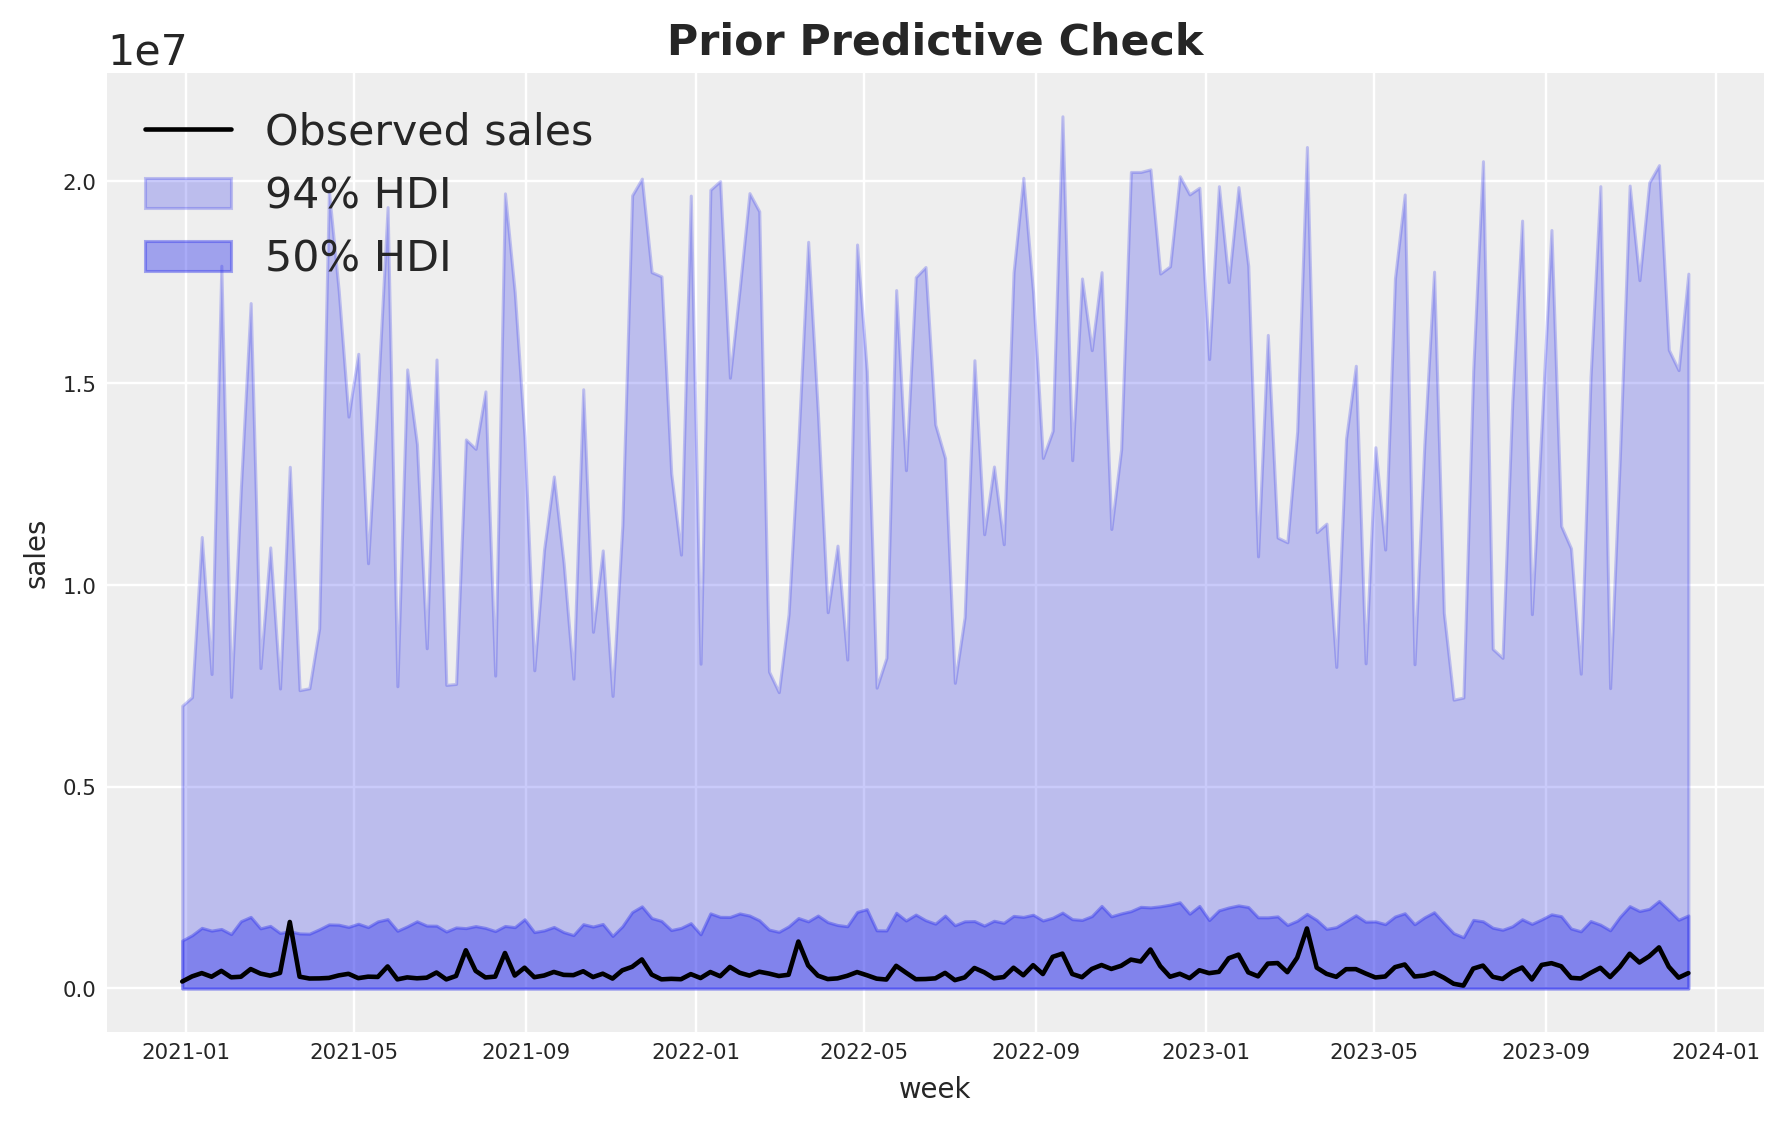

In [19]:
# Prior predictive checks answer a simple question:
# before fitting to data, are the priors at least capable of generating plausible sales?
mmm.sample_prior_predictive(X_train, y_train, samples=2_000)

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=train_df, x=date_column, y=target_column, color="black", label="Observed sales", ax=ax)

for i, hdi_prob in enumerate([0.94, 0.50]):
    az.plot_hdi(
        x=mmm.model.coords["date"],
        y=mmm.idata["prior"]["y_original_scale"].unstack().transpose(..., "date"),
        smooth=False,
        color="C0",
        hdi_prob=hdi_prob,
        fill_kwargs={"alpha": 0.25 + i * 0.15, "label": f"{hdi_prob:.0%} HDI"},
        ax=ax,
    )

ax.legend(loc="upper left")
ax.set_xlabel("week", fontsize=9)
ax.set_ylabel("sales", fontsize=9)
ax.set_title("Prior Predictive Check", fontsize=14, fontweight="bold")
ax.tick_params(axis="both", labelsize=7)
plt.show()


### Prior Predictive Check Summary

- The prior predictive distribution is intentionally **broad**, which means the priors are flexible enough to cover plausible sales values before seeing the data.
- Observed sales sit within the broader prior range, so the priors are not obviously mis-scaled.
- This is the right behavior at this stage: wide enough to be realistic, but not so narrow that the model is pre-committed before fitting.


## Prior Channel Contribution Share

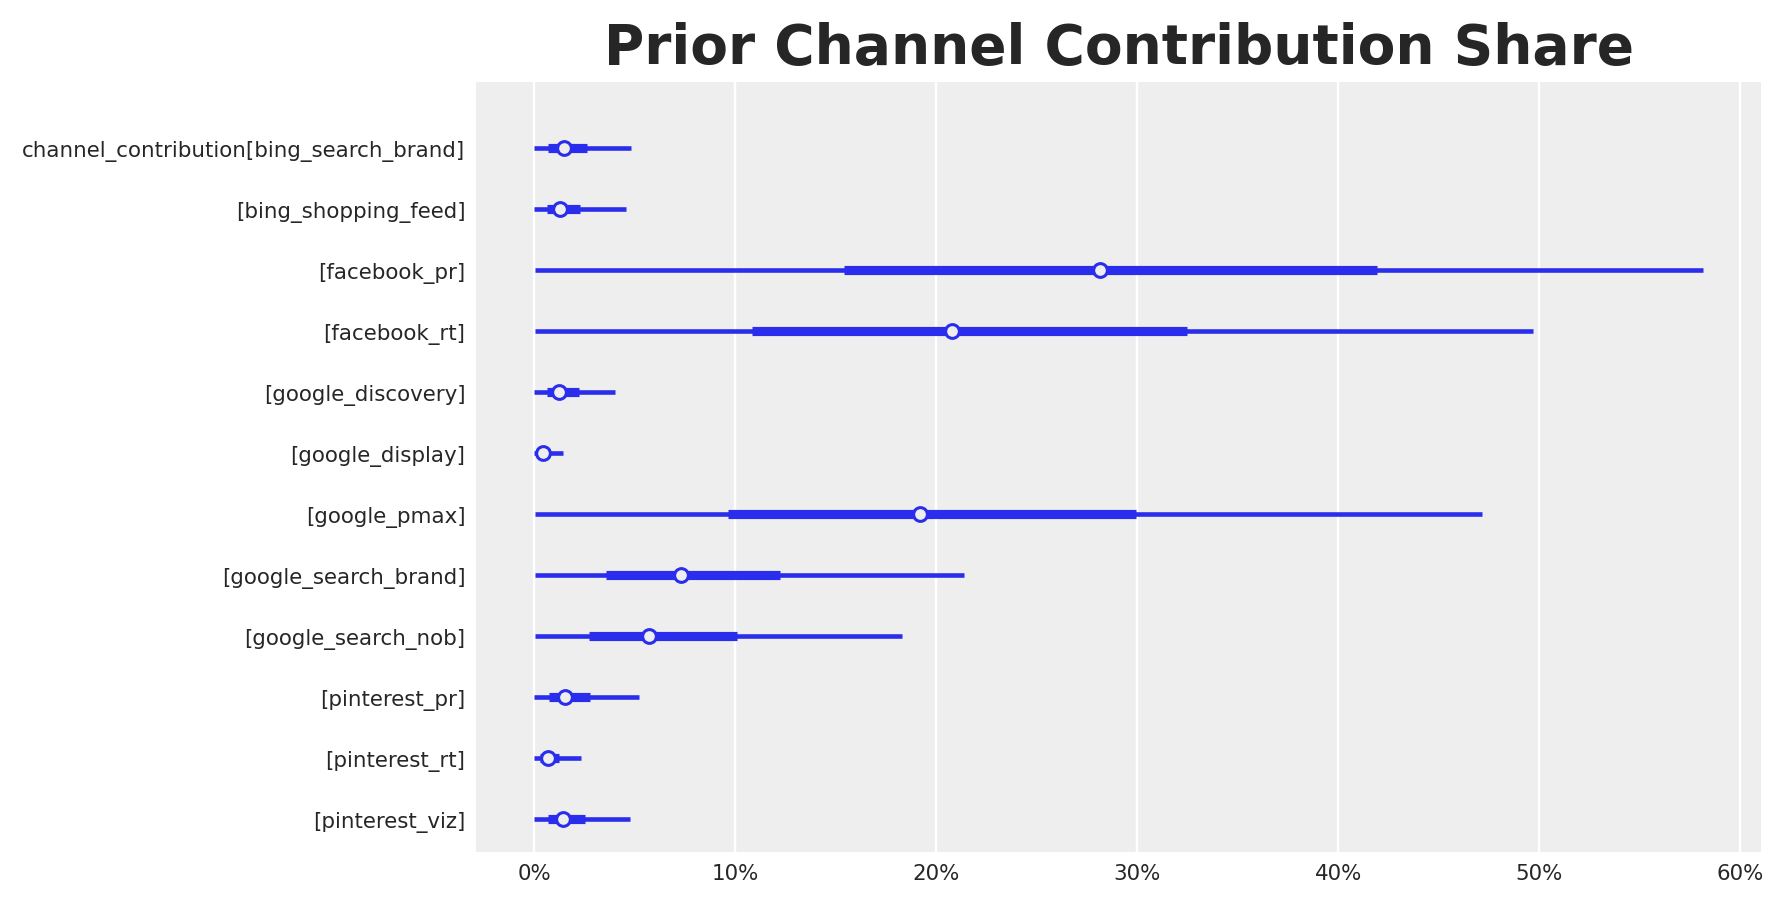

In [20]:
# Inspect how much contribution the priors allow each channel to explain before fitting.
sum_contributions = mmm.idata["prior"]["channel_contribution"].sum(dim="date")
share_contributions = sum_contributions / sum_contributions.sum(dim="channel")

fig, ax = plt.subplots(figsize=(8, 4))
az.plot_forest(share_contributions, combined=True, ax=ax)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title("Prior Channel Contribution Share", fontsize=18, fontweight="bold")
ax.tick_params(axis="both", labelsize=7)
plt.show()


### Prior Channel Contribution Share

- The priors leave **substantial uncertainty** about which channels will end up carrying the most contribution.
- Higher-spend channels are allowed a wider plausible range, but the data still determines the final attribution.



## Model Fitting

In [21]:
# Sampler configuration: 4 chains with target_accept=0.90.
# Convergence is checked below (divergences, R-hat, ESS, trace plots).
mmm.fit(
    X=X_train,
    y=y_train,
    target_accept=0.90,
    chains=4,
    draws=500,
    tune=700,
    random_seed=seed,
)

mmm.sample_posterior_predictive(X=X_train, random_seed=seed)


Output()

Output()

Output()

<xarray.Dataset> Size: 5MB
Dimensions:           (date: 155, sample: 2000)
Coordinates:
  * date              (date) datetime64[ns] 1kB 2020-12-29 ... 2023-12-12
  * sample            (sample) object 16kB MultiIndex
  * chain             (sample) int64 16kB 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3
  * draw              (sample) int64 16kB 0 1 2 3 4 5 ... 495 496 497 498 499
Data variables:
    y                 (date, sample) float64 2MB 0.0371 0.02001 ... 0.05394
    y_original_scale  (date, sample) float64 2MB 6.111e+04 ... 8.885e+04
Attributes:
    created_at:                 2026-03-11T02:18:19.674907+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.28.1

## Model Diagnostics

In [22]:
# Divergences are a quick sanity check for sampler problems.
divergences = mmm.idata["sample_stats"]["diverging"].sum().item()
print(f"Diverging transitions: {divergences}")


Diverging transitions: 0


In [23]:
# Summarize the key parameters we care about for convergence and scale.
az.summary(
    data=mmm.idata,
    var_names=[
        "intercept_contribution",
        "y_sigma",
        "saturation_beta",
        "saturation_lam",
        "adstock_alpha",
        "gamma_control",
        "gamma_fourier",
    ],
)[["mean", "sd", "r_hat", "ess_bulk"]].head(20)


,mean,sd,r_hat,ess_bulk
intercept_contribution,-0.087,0.040,1.00,1243.0
y_sigma,0.090,0.006,1.00,1733.0
saturation_beta[bing_search_brand],0.011,0.008,1.00,1203.0
saturation_beta[bing_shopping_feed],0.012,0.009,1.00,1210.0
saturation_beta[facebook_pr],0.061,0.045,1.00,1377.0
saturation_beta[facebook_rt],0.115,0.070,1.00,948.0
saturation_beta[google_discovery],0.026,0.018,1.01,1135.0
saturation_beta[google_display],0.007,0.006,1.00,1438.0
saturation_beta[google_pmax],0.137,0.043,1.00,1188.0
saturation_beta[google_search_brand],0.267,0.058,1.00,1784.0


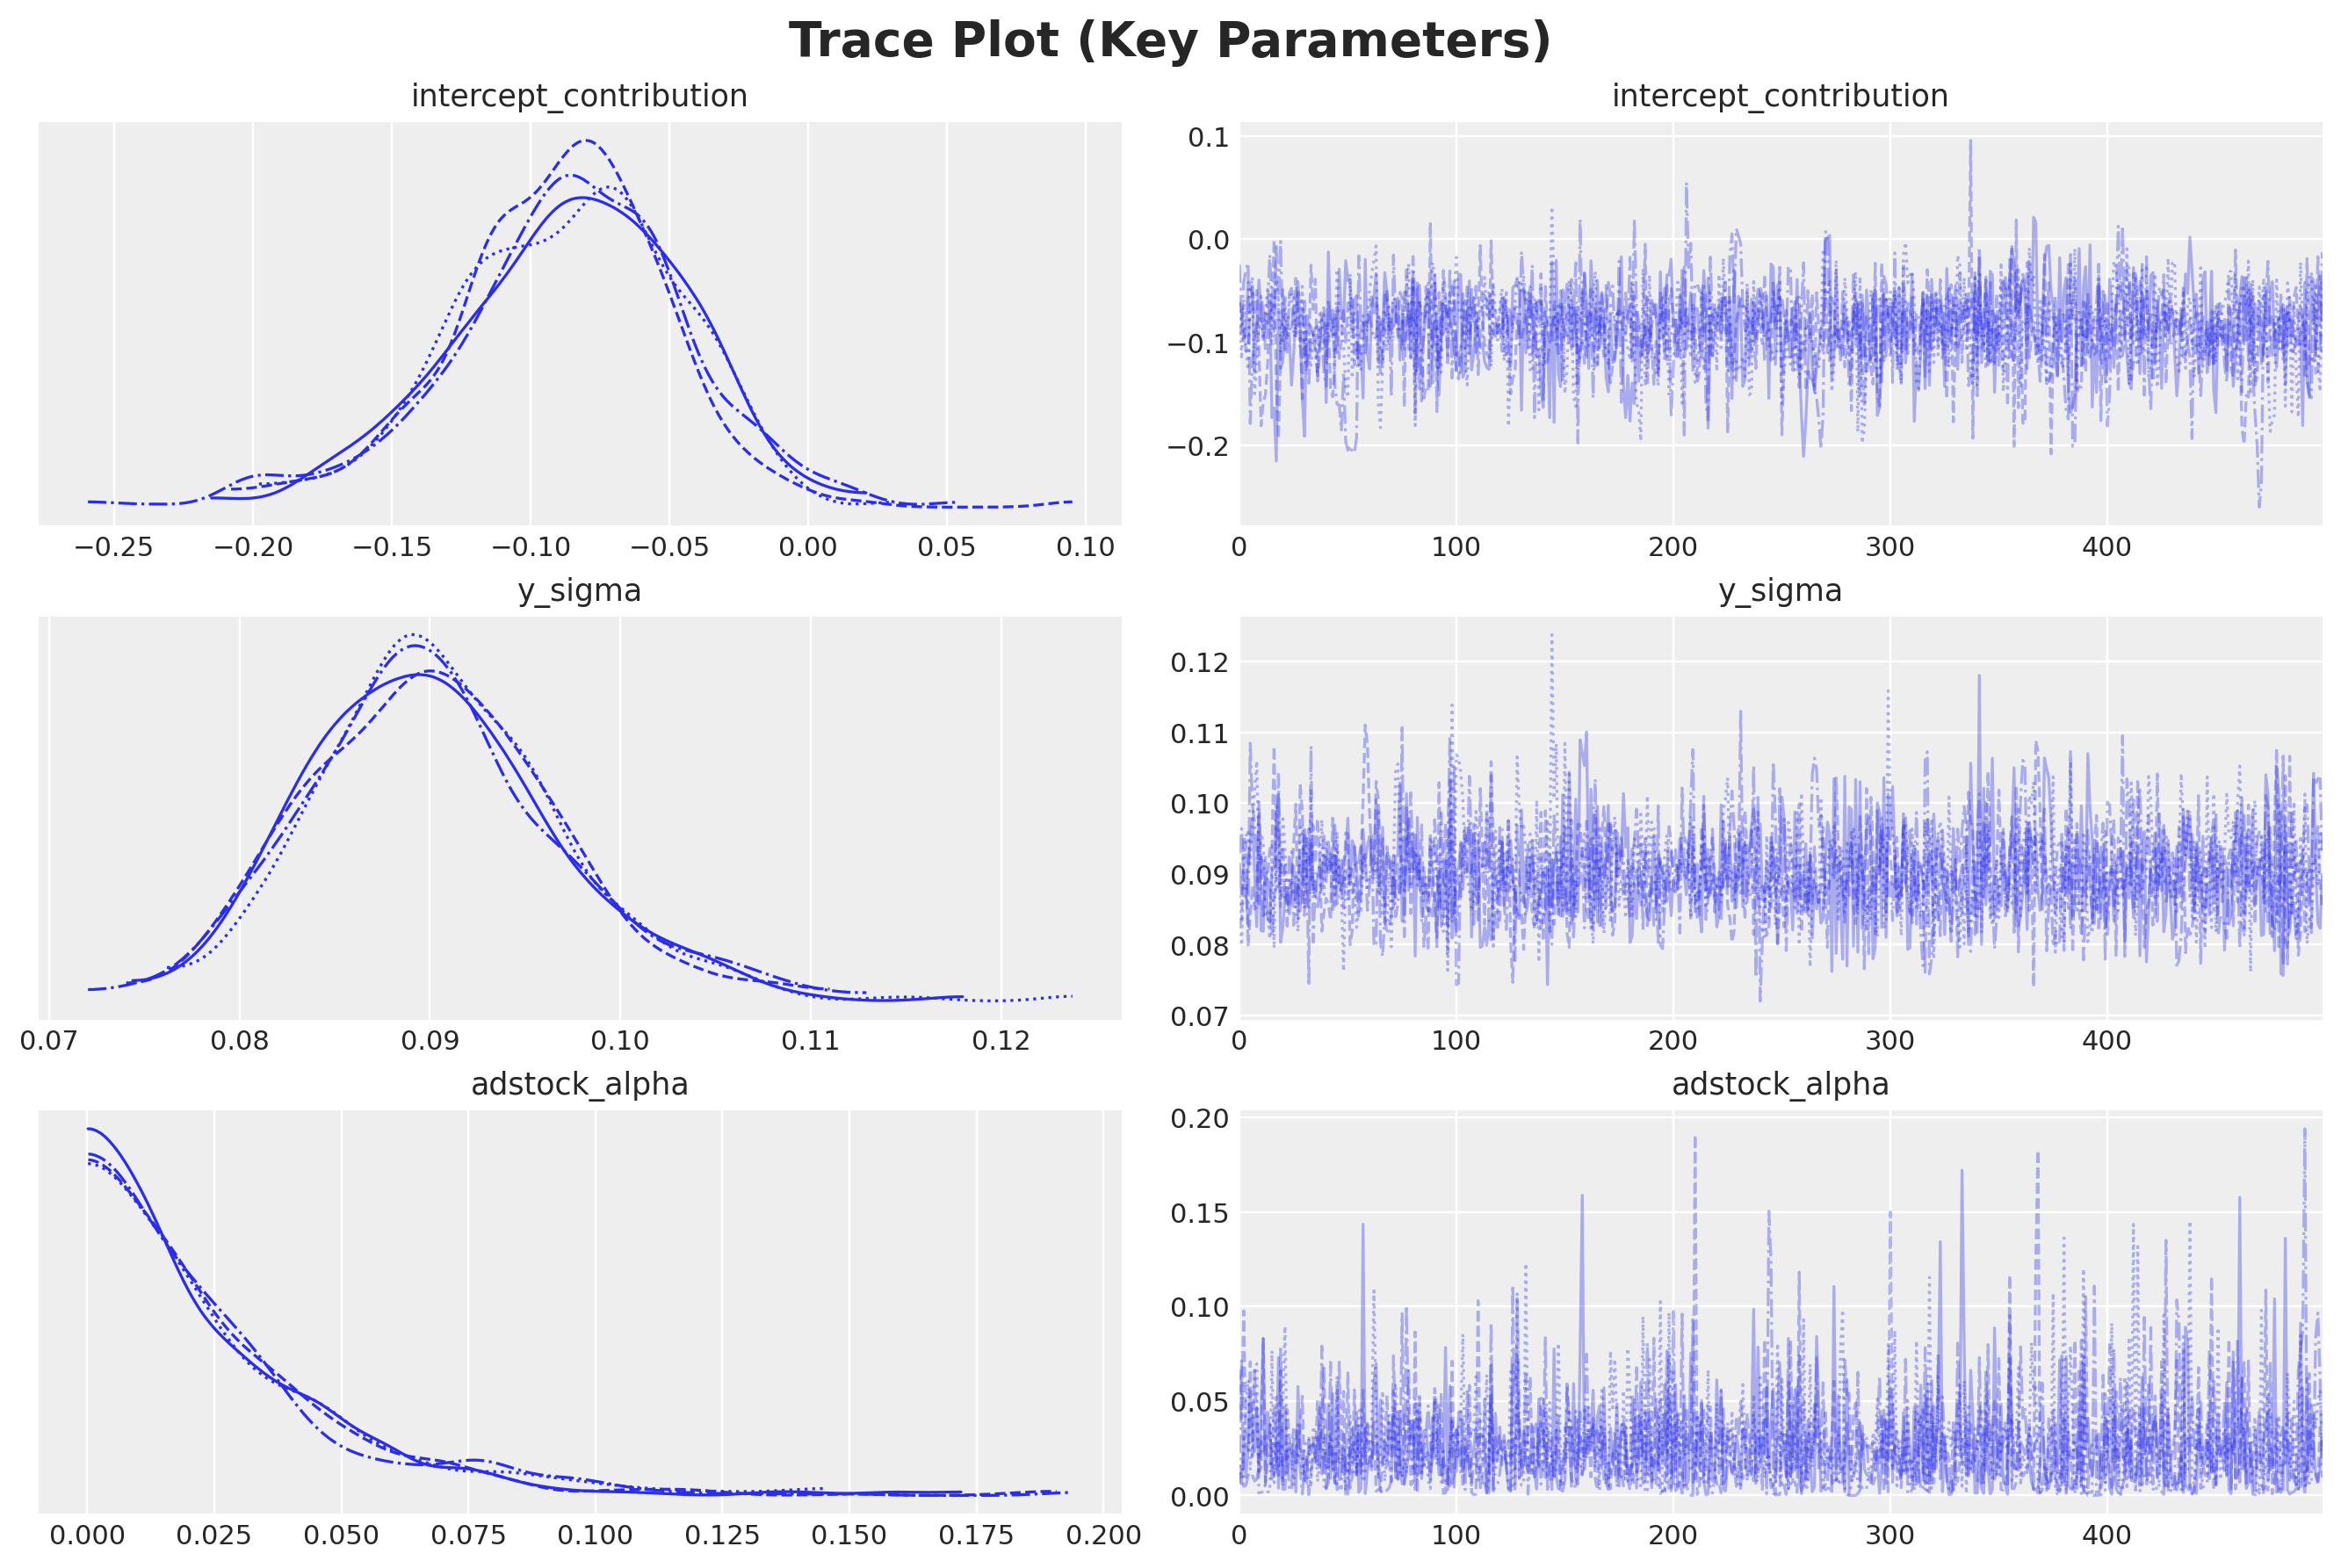

In [24]:
# Trace plots complement R-hat and ESS by showing chain mixing directly.
_ = az.plot_trace(
    data=mmm.fit_result,
    var_names=["intercept_contribution", "y_sigma", "adstock_alpha"],
    compact=True,
    backend_kwargs={"figsize": (12, 8), "layout": "constrained"},
)
plt.gcf().suptitle("Trace Plot (Key Parameters)", fontsize=18, fontweight="bold")
plt.show()


## Posterior Predictive Checks

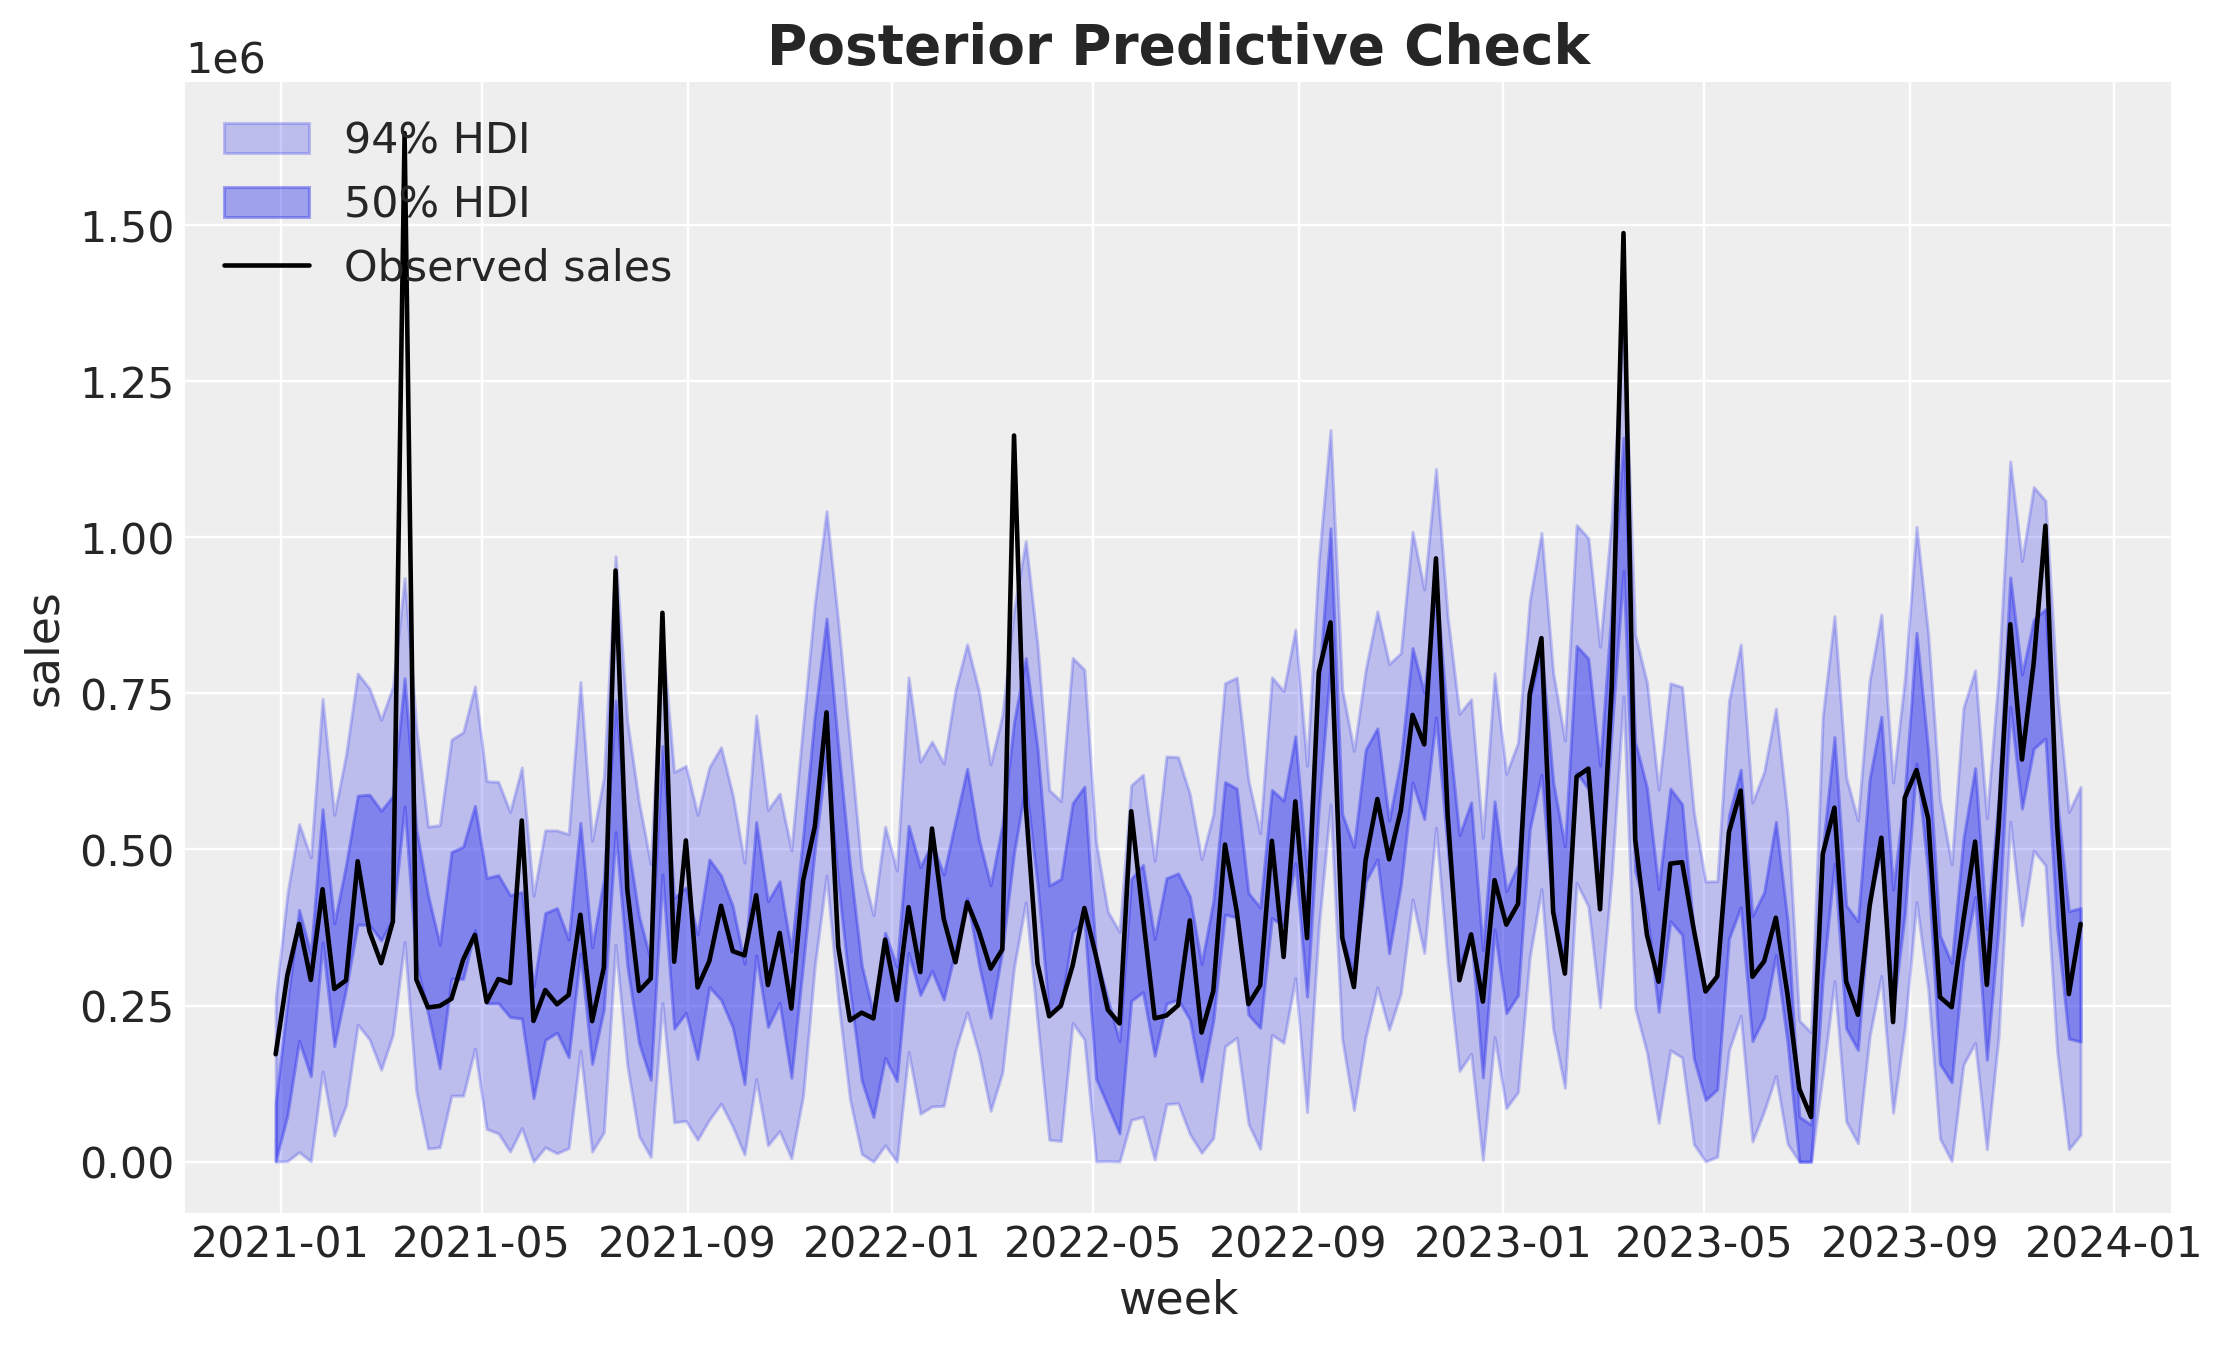

In [25]:
# Compare the fitted posterior predictive distribution with observed training sales.
fig, ax = plt.subplots(figsize=(10, 6))

posterior_y = mmm.idata.posterior_predictive["y_original_scale"]

for i, hdi_prob in enumerate([0.94, 0.50]):
    az.plot_hdi(
        x=mmm.model.coords["date"],
        y=posterior_y,
        color="C0",
        smooth=False,
        hdi_prob=hdi_prob,
        fill_kwargs={"alpha": 0.25 + i * 0.15, "label": f"{hdi_prob:.0%} HDI"},
        ax=ax,
    )

sns.lineplot(
    data=train_df,
    x=date_column,
    y=target_column,
    color="black",
    label="Observed sales",
    ax=ax,
)

ax.legend(loc="upper left")
ax.set(xlabel="week", ylabel="sales")
ax.set_title("Posterior Predictive Check", fontsize=18, fontweight="bold")
plt.show()


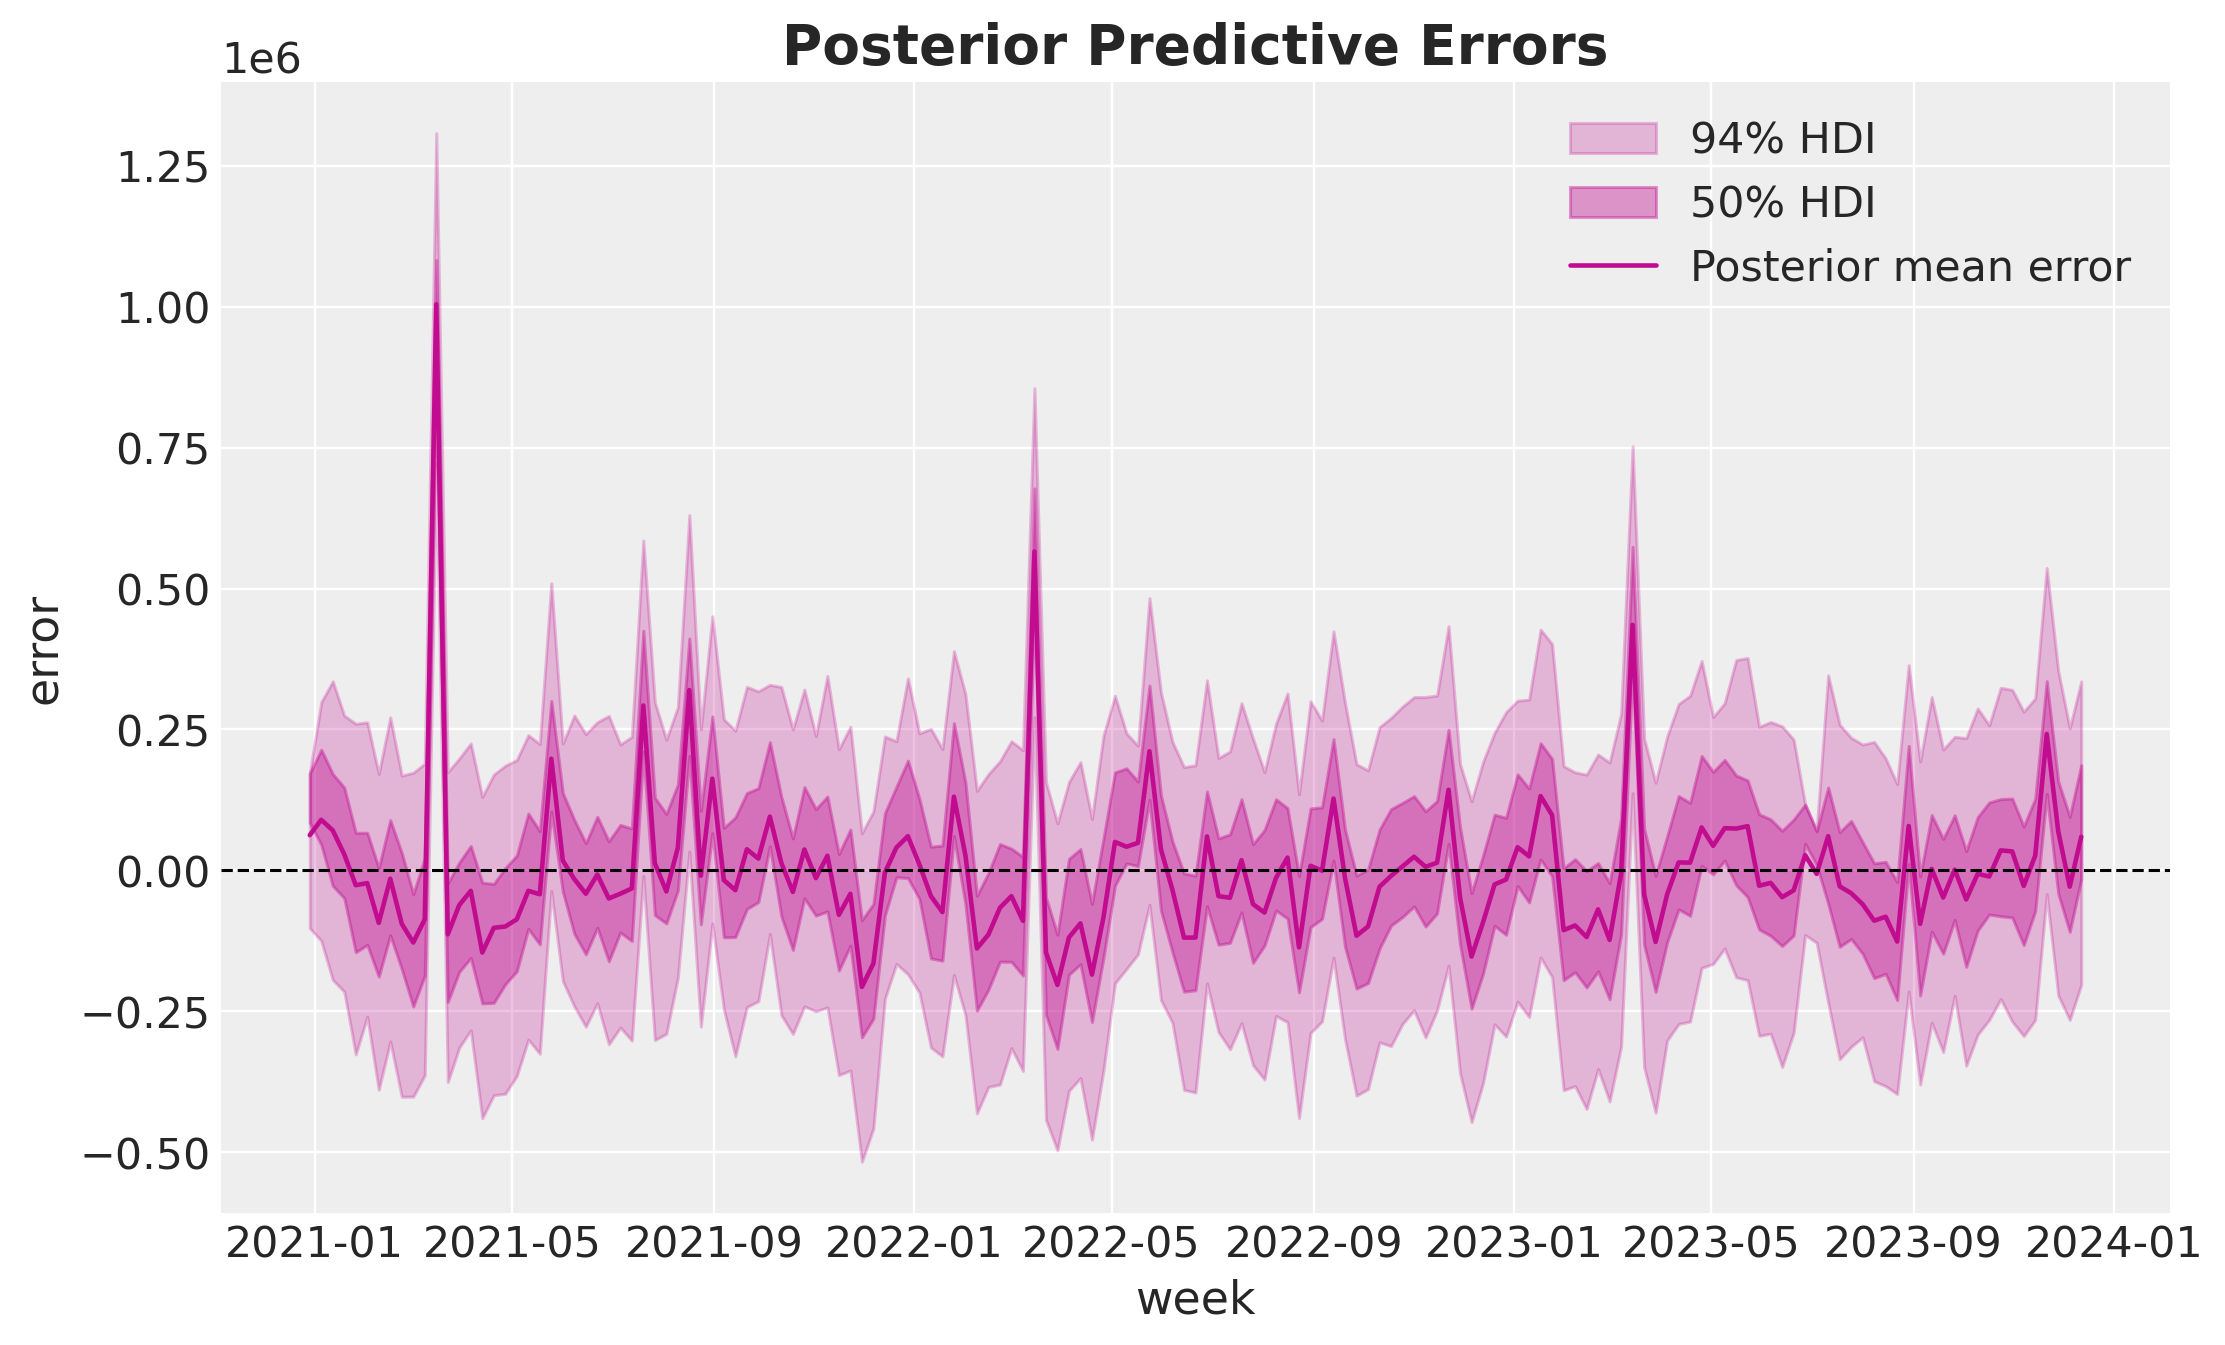

In [26]:
# Plot posterior predictive errors. If the model is broadly well-calibrated,
# these errors should oscillate around zero rather than drifting strongly positive or negative.
errors = y_train.to_numpy()[np.newaxis, np.newaxis, :] - mmm.idata["posterior"]["y_original_scale"]

fig, ax = plt.subplots(figsize=(10, 6))
for i, hdi_prob in enumerate([0.94, 0.50]):
    az.plot_hdi(
        x=mmm.model.coords["date"],
        y=errors,
        color="C3",
        smooth=False,
        hdi_prob=hdi_prob,
        fill_kwargs={"alpha": 0.25 + i * 0.15, "label": f"{hdi_prob:.0%} HDI"},
        ax=ax,
    )

sns.lineplot(
    x=mmm.model.coords["date"],
    y=errors.mean(dim=("chain", "draw")),
    color="C3",
    label="Posterior mean error",
    ax=ax,
)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set(xlabel="week", ylabel="error")
ax.set_title("Posterior Predictive Errors", fontsize=18, fontweight="bold")
ax.legend()
plt.show()


## Posterior Model Diagnostics

- Sampler diagnostics are healthy: **R-hat is approximately 1.00**, effective sample sizes are comfortably large, and the trace plots show reasonable mixing.
- The posterior for **adstock_alpha** sits at relatively low values, which implies channel effects decay fairly quickly rather than persisting across many weeks.
- The posterior predictive fit captures the **overall level and volatility** of sales reasonably well, although the most extreme spikes are still difficult to reproduce.
- Errors are centered roughly around zero, which suggests the model is not badly biased in one direction.


## Model Contribution Analysis

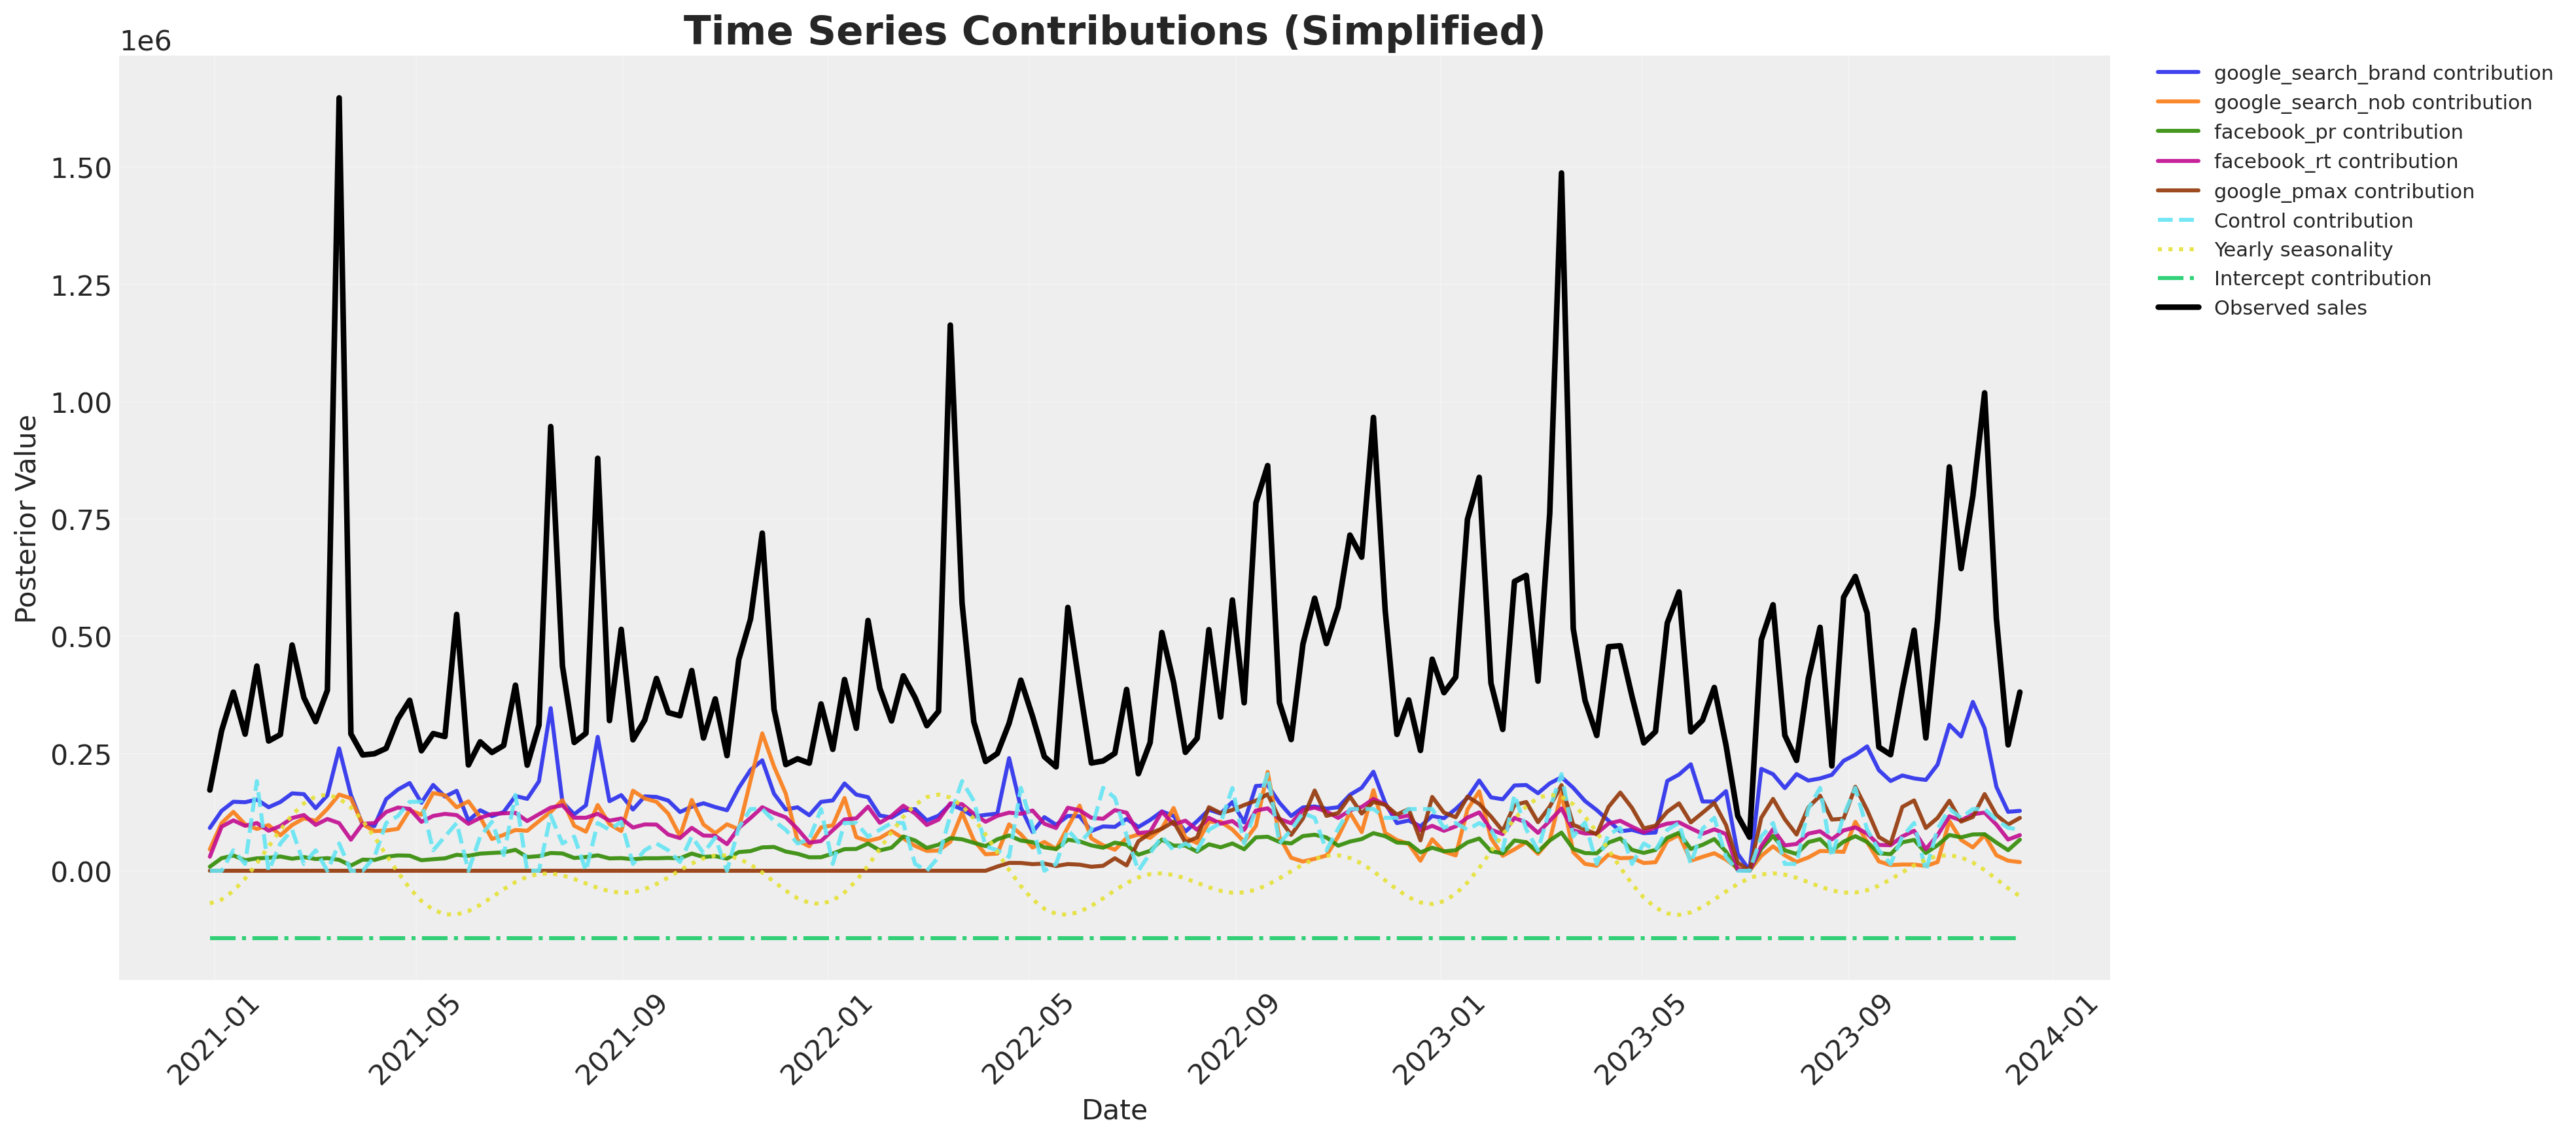

In [27]:
# Plot only the main channels plus controls, seasonality, and baseline.
# The full decomposition is informative, but this simplified view is easier to explain live.

selected_channels = [
    "google_search_brand",
    "google_search_nob",
    "facebook_pr",
    "facebook_rt",
    "google_pmax",
]

fig, ax = plt.subplots(figsize=(18, 8))

idata = mmm.idata.posterior
dates = np.array(mmm.model.coords["date"])

for ch in selected_channels:
    mean_contrib = (
        idata["channel_contribution_original_scale"]
        .sel(channel=ch)
        .mean(dim=("chain", "draw"))
        .values
    )
    ax.plot(
        dates,
        mean_contrib,
        linewidth=2,
        label=f"{ch} contribution",
        alpha=0.9,
    )

if "control_contribution_original_scale" in idata:
    control_mean = (
        idata["control_contribution_original_scale"]
        .mean(dim=("chain", "draw"))
        .sum(dim="control")
        .values
    )
    ax.plot(
        dates,
        control_mean,
        linewidth=2,
        linestyle="--",
        label="Control contribution",
        alpha=0.9,
    )

if "yearly_seasonality_contribution_original_scale" in idata:
    seasonality_mean = (
        idata["yearly_seasonality_contribution_original_scale"]
        .mean(dim=("chain", "draw"))
        .values
    )
    ax.plot(
        dates,
        seasonality_mean,
        linewidth=2,
        linestyle=":",
        label="Yearly seasonality",
        alpha=0.9,
    )

if "intercept_contribution_original_scale" in idata:
    intercept_mean = (
        idata["intercept_contribution_original_scale"]
        .mean(dim=("chain", "draw"))
        .values
    )

    if np.ndim(intercept_mean) == 0 or len(np.atleast_1d(intercept_mean)) == 1:
        intercept_series = np.repeat(float(np.ravel(intercept_mean)[0]), len(dates))
    else:
        intercept_series = intercept_mean

    ax.plot(
        dates,
        intercept_series,
        linewidth=2,
        linestyle="-.",
        label="Intercept contribution",
        alpha=0.9,
    )

sns.lineplot(
    data=train_df,
    x=date_column,
    y=target_column,
    color="black",
    linewidth=2.8,
    label="Observed sales",
    ax=ax,
    zorder=10,
)

ax.set_title("Time Series Contributions (Simplified)", fontsize=20, fontweight="bold")
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Posterior Value", fontsize=14)
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    frameon=False,
    fontsize=10,
)
ax.grid(True, alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


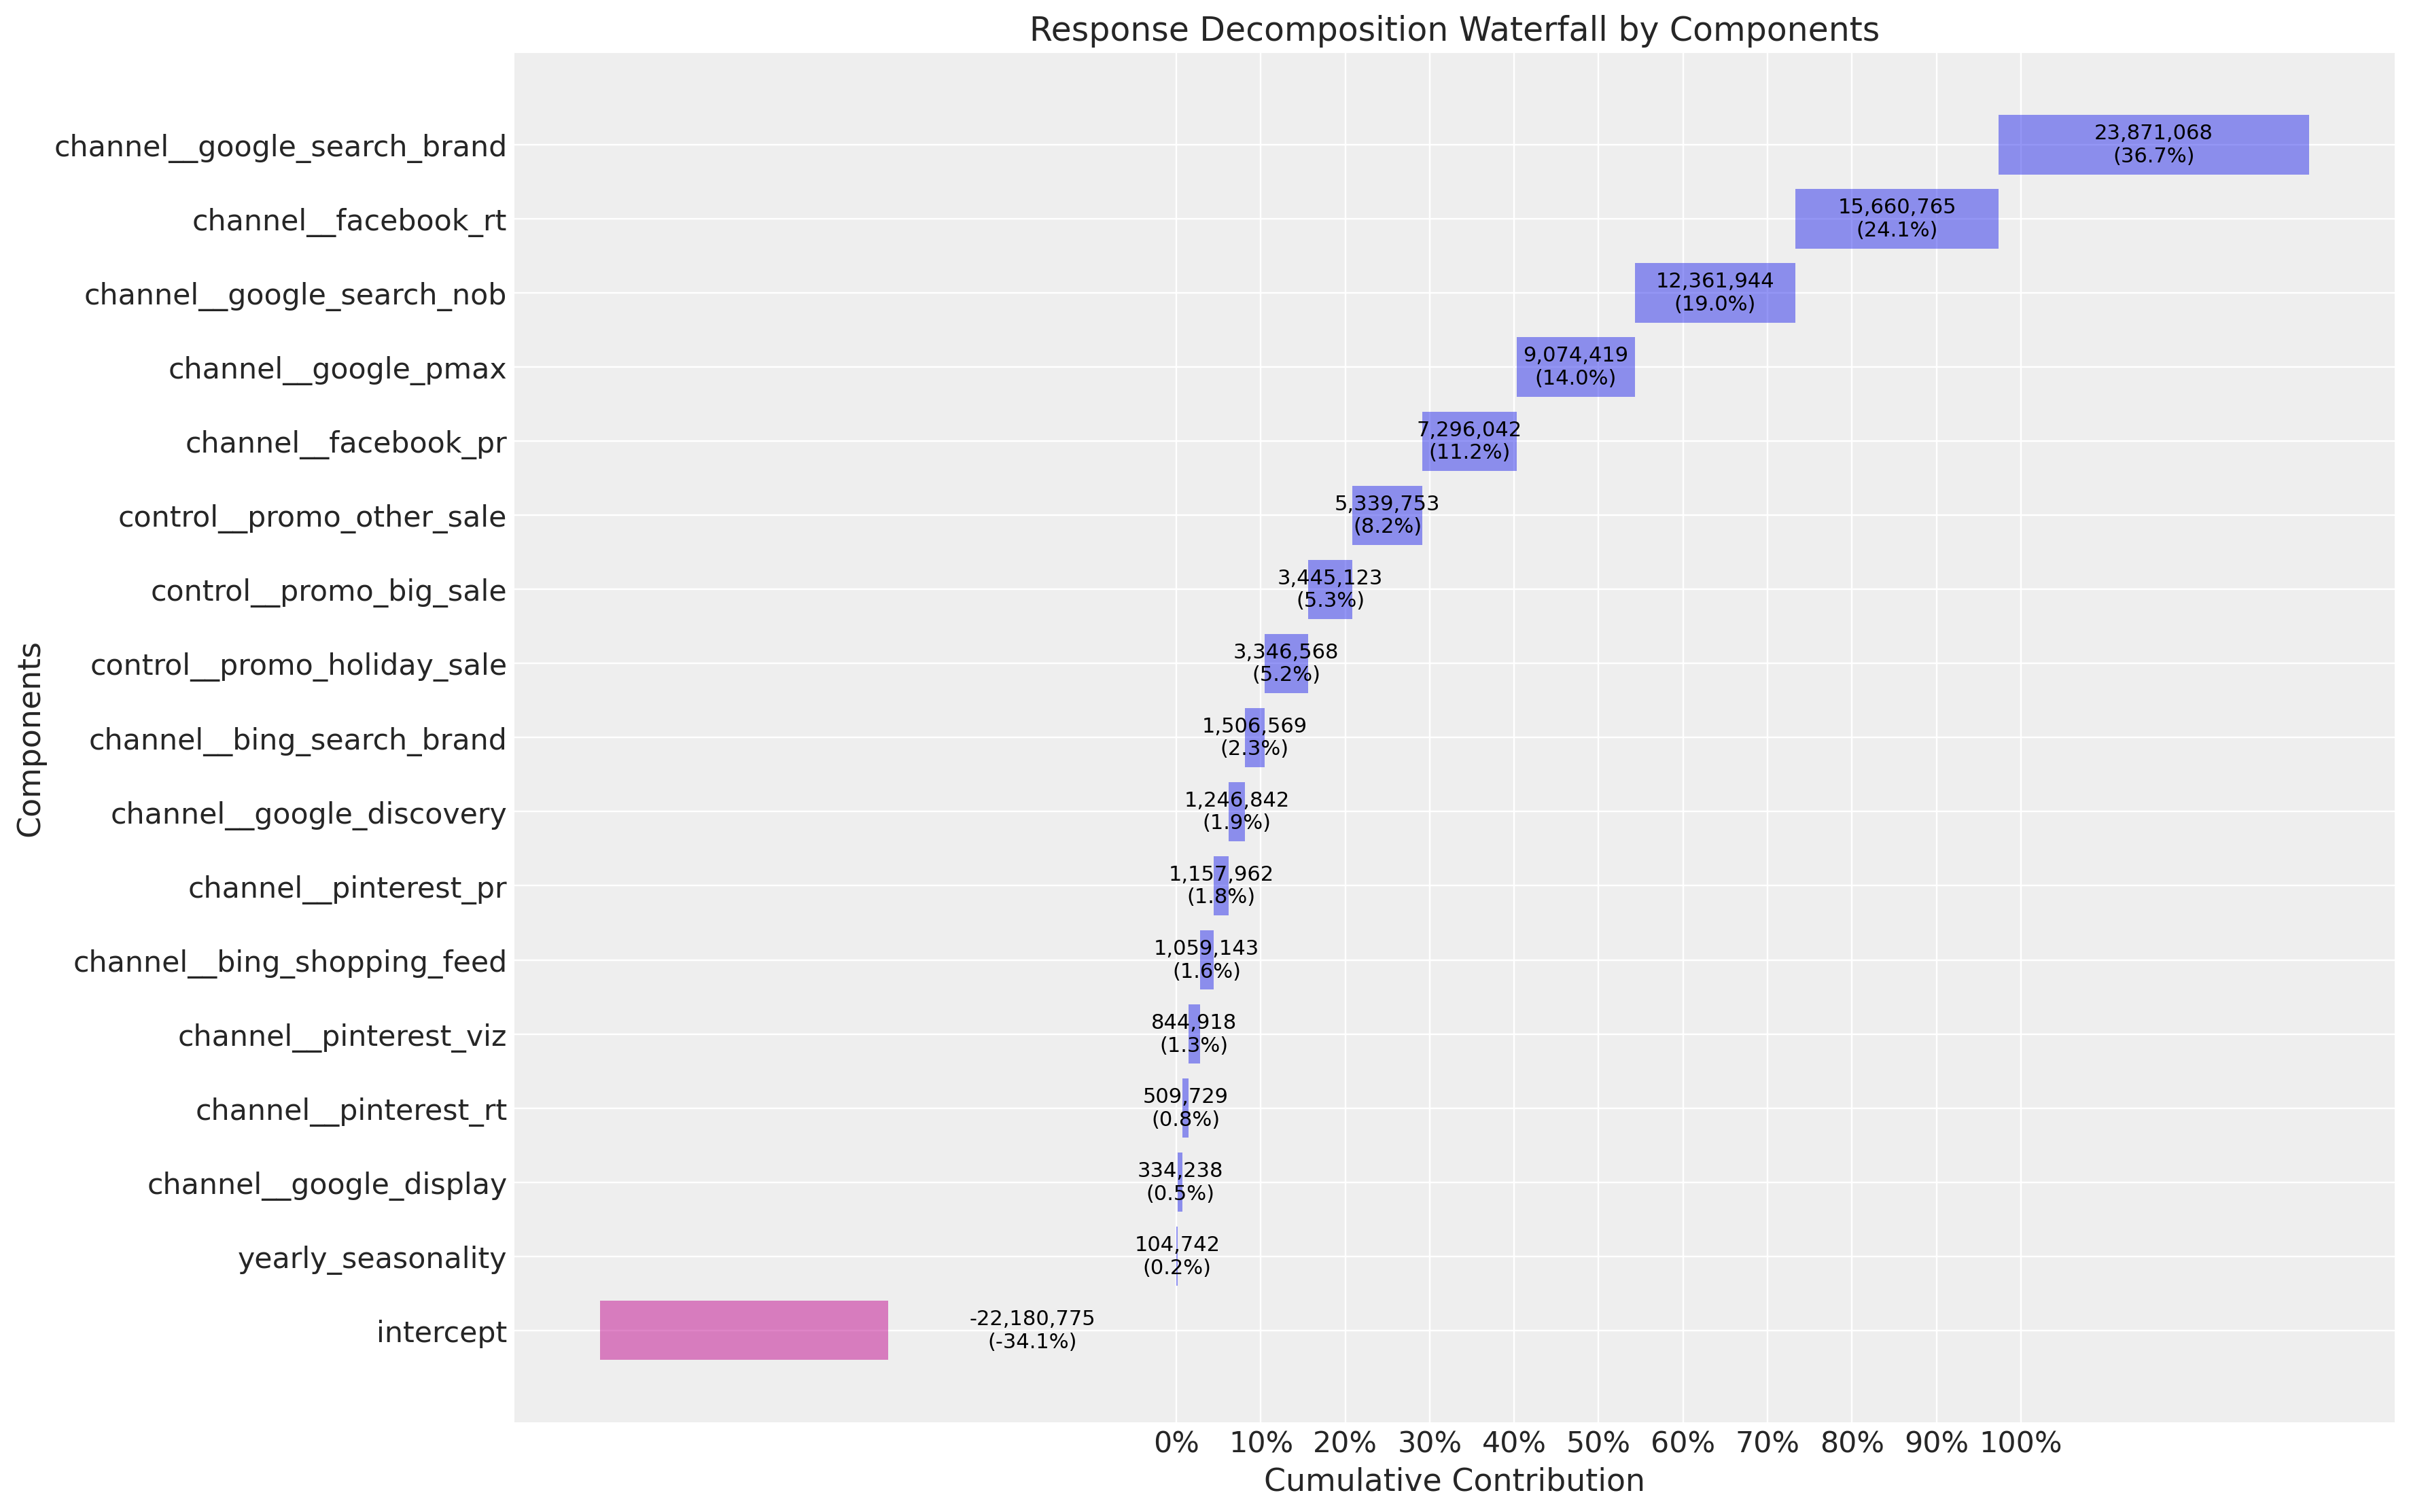

In [28]:
# The waterfall view summarizes how total modeled sales decompose across channels and controls.
fig, ax = mmm.plot.waterfall_components_decomposition(figsize=(16, 10))
plt.show()


The waterfall chart is especially useful for business storytelling because it answers:  
**Which components account for the largest share of modeled sales over the full time window?**


## Overall Contribution Breakdown

- **Google Search Brand** is the largest single modeled driver of sales, followed by **Facebook Retargeting**, **Google Search Non-Brand**, and **Google PMax**.
- Promotions also matter: the promo controls contribute meaningful uplift, which confirms that sales spikes are not purely media-driven.
- The intercept is negative in this fitted model, which means the model is pushing more explanatory weight toward media and promo components than toward a neutral baseline.




In [29]:
# Response curves show how spend translates into contribution for each channel.
# A flattening curve indicates diminishing returns at higher spend levels.
mmm.plot.saturation_scatterplot(
    width_per_col=10,
    height_per_row=4,
    original_scale=True,
)
plt.show()


## Channel Response Curves — Key Findings

- The response curves show **clear diminishing returns** across most channels, which is exactly the saturation behavior we expect in MMM.
- **Google Search Brand**, **Google Search Non-Brand**, and **Facebook Retargeting** stand out as the highest-magnitude response curves.
- **Google PMax** also scales meaningfully, but with visible flattening at higher spend.
- Smaller channels remain positive but operate at much lower absolute contribution levels.


### Return on Ad Spend (ROAS)

In [30]:
# Estimate simple posterior mean ROAS as contribution divided by spend.
# This is useful directionally, but it should be interpreted together with
# multicollinearity risk and the saturation curves.
channel_contribution = (
    mmm.idata["posterior"]["channel_contribution_original_scale"]
    .mean(dim=("chain", "draw"))
    .sum(dim="date")
    .to_series()
)

channel_spend = X_train[channel_columns].sum(axis=0)
roas_df = pd.DataFrame({
    "channel": channel_columns,
    "contribution": [channel_contribution.get(ch, np.nan) for ch in channel_columns],
    "spend": [channel_spend[ch] for ch in channel_columns],
})
roas_df["roas"] = roas_df["contribution"] / roas_df["spend"]
roas_df = roas_df.sort_values("roas", ascending=False)
roas_df


,channel,contribution,spend,roas
1,google_search_brand,2.387107e+07,7.527003e+05,31.713908
6,bing_search_brand,1.506569e+06,1.049575e+05,14.354087
2,google_search_nob,1.236194e+07,8.816606e+05,14.021205
4,facebook_rt,1.566076e+07,1.391716e+06,11.252849
0,google_display,3.342378e+05,3.979309e+04,8.399393
7,bing_shopping_feed,1.059143e+06,1.398546e+05,7.573174
10,pinterest_rt,5.097286e+05,6.785535e+04,7.511989
9,pinterest_pr,1.157962e+06,1.707827e+05,6.780321
5,google_discovery,1.246842e+06,2.355940e+05,5.292334
8,pinterest_viz,8.449183e+05,1.890560e+05,4.469144


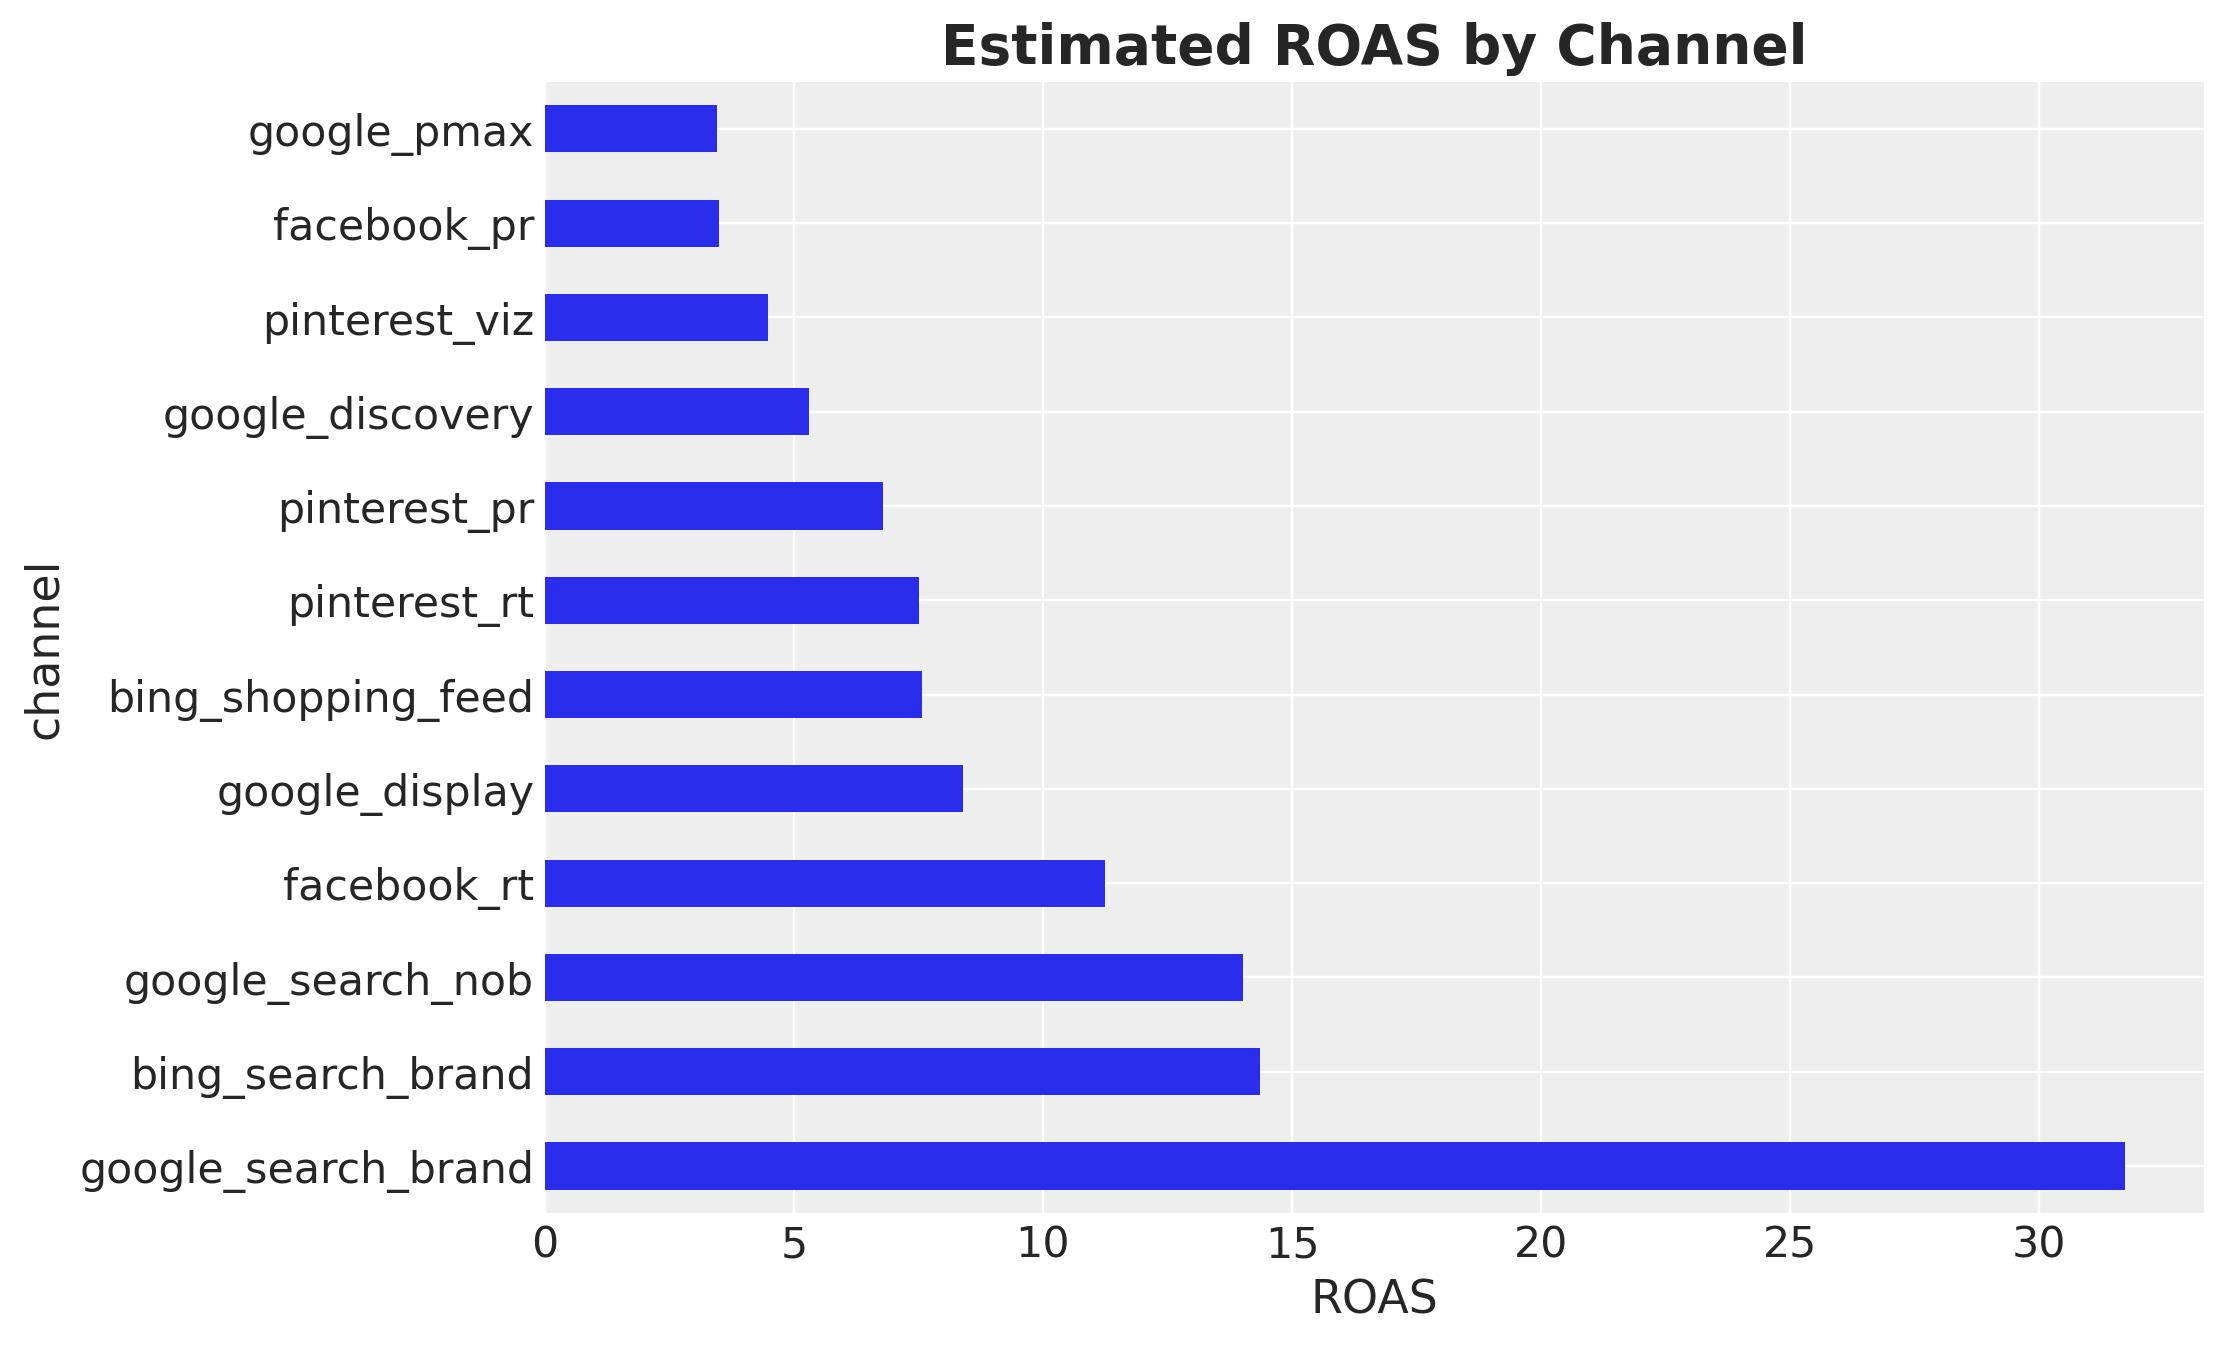

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))
roas_df.plot.barh(x="channel", y="roas", legend=False, ax=ax)
ax.set(xlabel="ROAS", ylabel="channel")
ax.set_title("Estimated ROAS by Channel", fontsize=18, fontweight="bold")
plt.show()


The ROAS view should be treated as a **directional efficiency ranking**, not a final budget recommendation in isolation.  
Channels that move together in the data can still look strong individually even when attribution is shared.


## Channel Efficiency and Correlation Analysis — Key Findings

- **Google Search Brand** has the highest estimated ROAS by a wide margin, with **Bing Search Brand**, **Google Search Non-Brand**, and **Facebook Retargeting** forming the next efficiency tier.
- This is directionally consistent with the contribution and correlation results: **search and retargeting appear to be the strongest conversion-oriented channels in the mix**.
- At the same time, the correlation analysis shows that some channels move together strongly enough to create attribution ambiguity, especially **Google Search Brand ↔ Bing Search Brand** and several **Pinterest/Facebook** combinations.
- Because of that overlap, ROAS should be interpreted as **informative but not perfectly causal**.


## Out-of-Sample Predictions

In [32]:
# Generate test-period posterior predictions without mutating the stored InferenceData object.
y_pred_test = mmm.sample_posterior_predictive(
    X_test,
    include_last_observations=True,
    random_seed=seed,
    extend_idata=False,
)

y_pred_train = mmm.idata["posterior_predictive"]["y_original_scale"]
y_pred_test_arr = y_pred_test["y_original_scale"].unstack().transpose(..., "date")


Output()

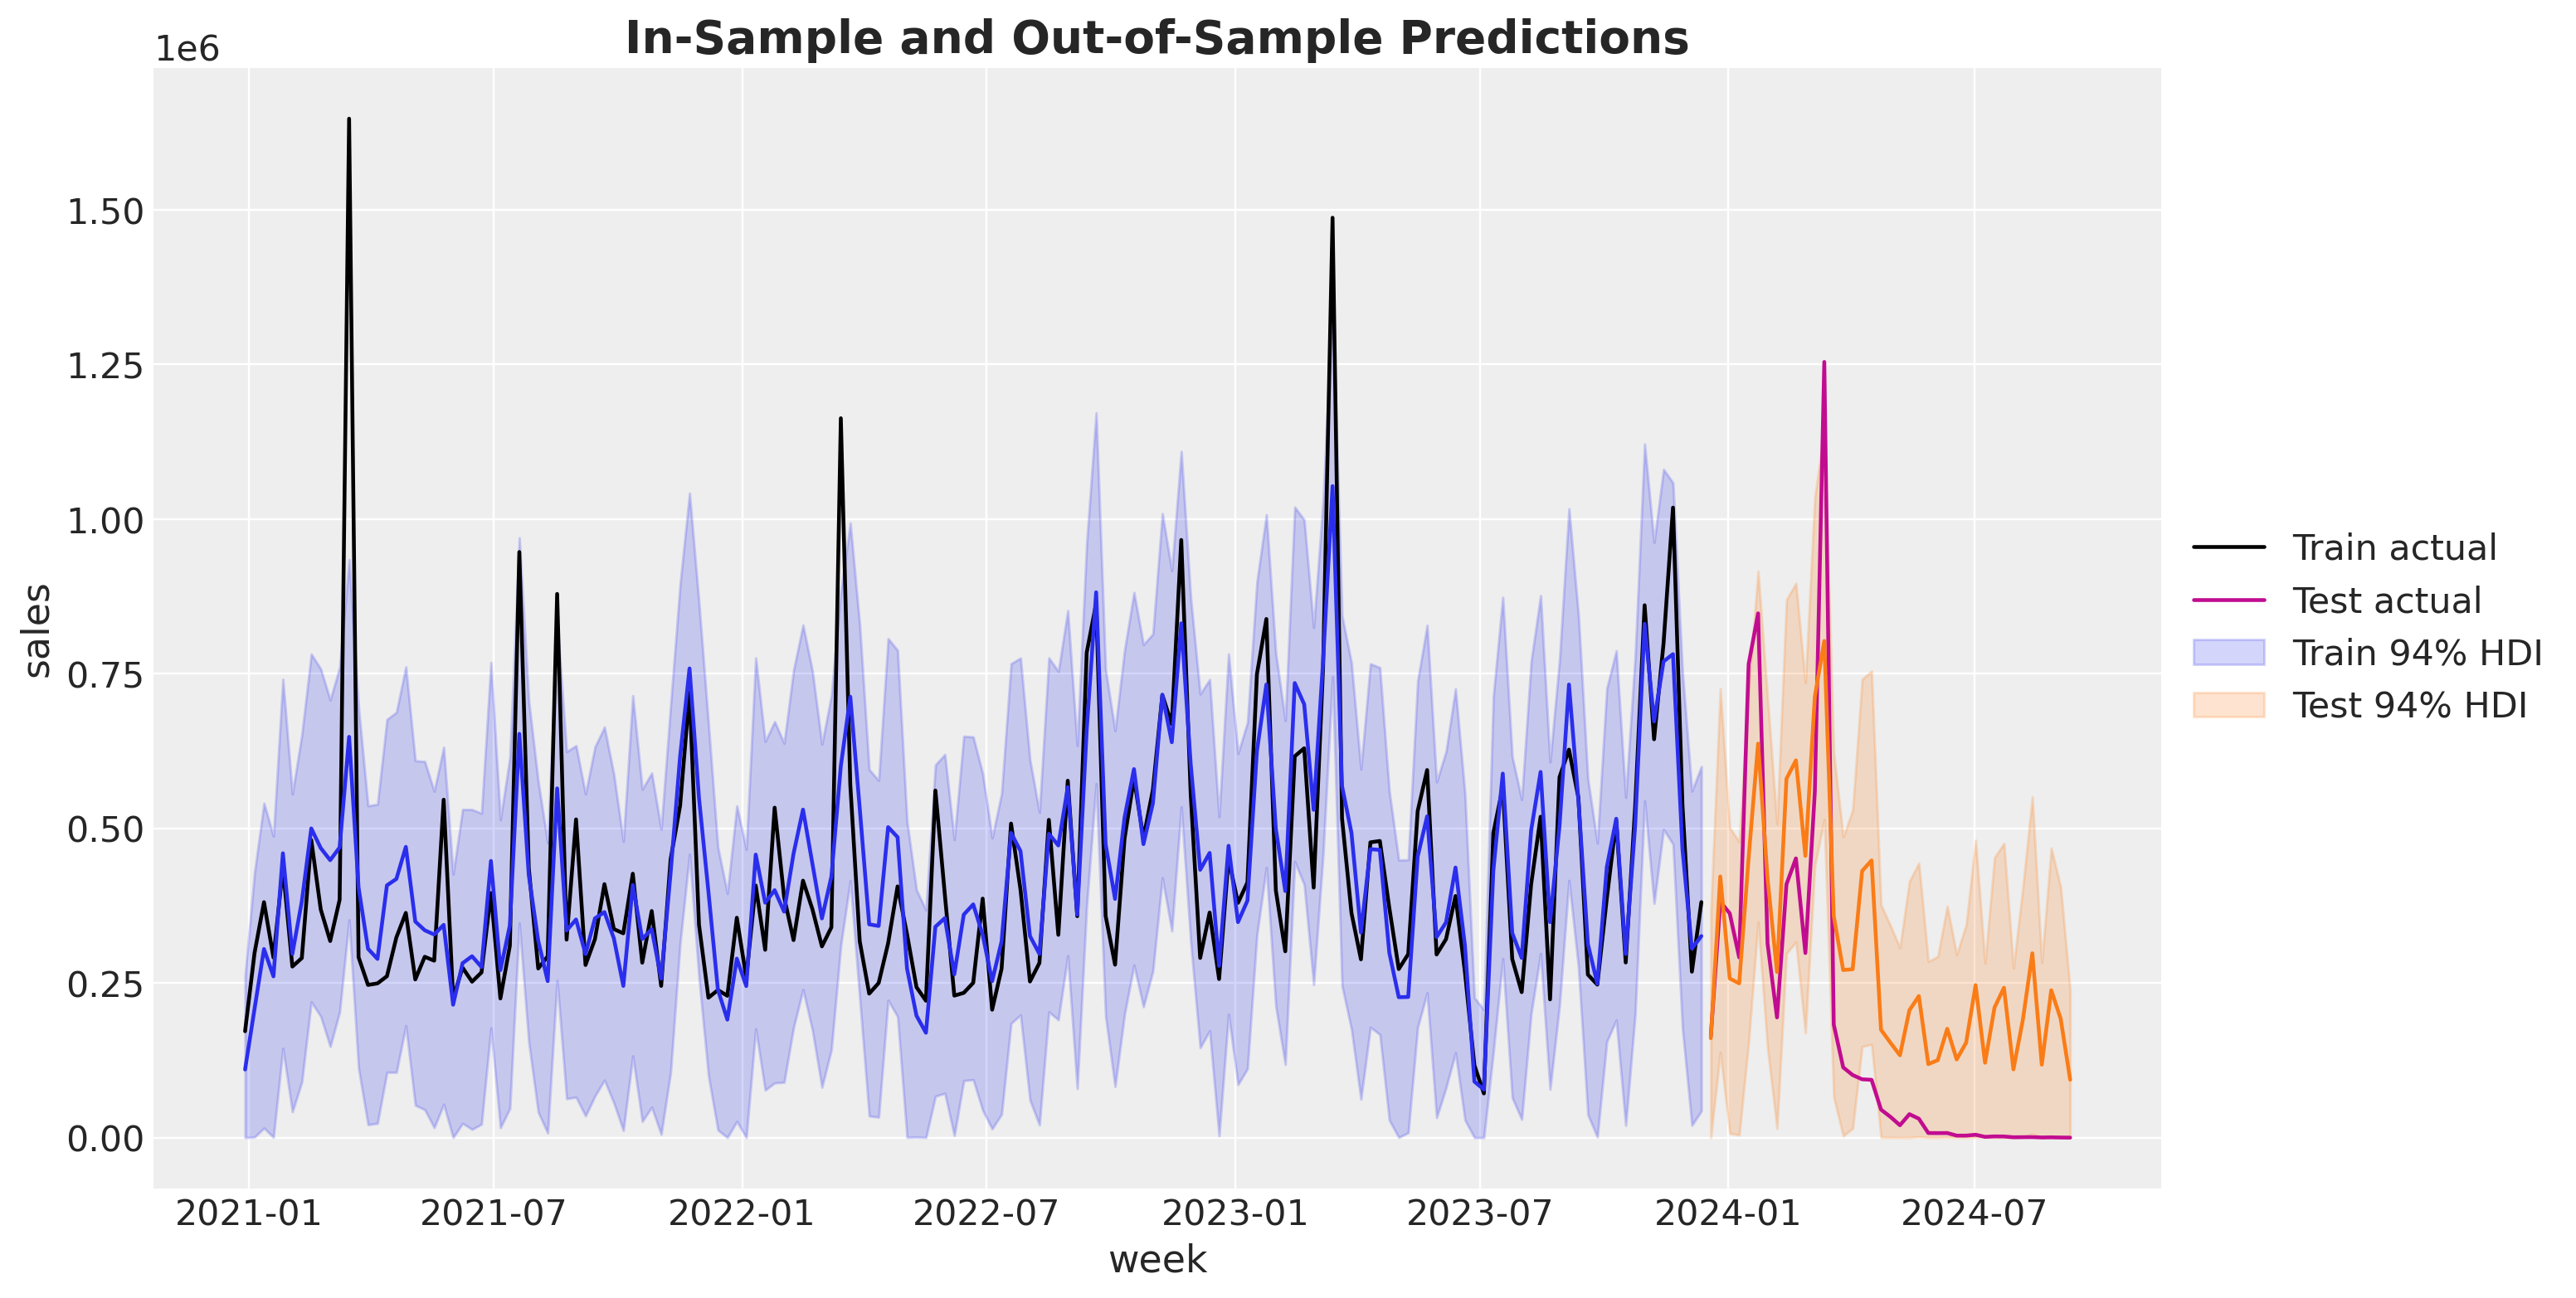

In [33]:
fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(data=train_df, x=date_column, y=target_column, color="black", label="Train actual", ax=ax)
sns.lineplot(data=test_df, x=date_column, y=target_column, color="C3", label="Test actual", ax=ax)

az.plot_hdi(
    X_train[date_column],
    y_pred_train,
    hdi_prob=0.94,
    color="C0",
    fill_kwargs={"alpha": 0.20, "label": "Train 94% HDI"},
    smooth=False,
    ax=ax,
)

az.plot_hdi(
    X_test[date_column],
    y_pred_test_arr,
    hdi_prob=0.94,
    color="C1",
    fill_kwargs={"alpha": 0.20, "label": "Test 94% HDI"},
    smooth=False,
    ax=ax,
)

ax.plot(X_train[date_column], y_pred_train.mean(dim=("chain", "draw")), color="C0")
ax.plot(X_test[date_column], y_pred_test_arr.mean(dim=("chain", "draw")), color="C1")
ax.set(xlabel="week", ylabel="sales")
ax.set_title("In-Sample and Out-of-Sample Predictions", fontsize=18, fontweight="bold")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()


In [34]:
# CRPS is a probabilistic forecast metric: lower is better.
crps_train = crps(y_train.to_numpy(), y_pred_train.stack(sample=("chain", "draw")).values.T)
crps_test = crps(y_test.to_numpy(), y_pred_test_arr.stack(sample=("chain", "draw")).values.T)

print(f"CRPS (train): {crps_train:.2f}")
print(f"CRPS (test): {crps_test:.2f}")


CRPS (train): 63879.28
CRPS (test): 111221.01


## Model Predictive Performance — Key Findings

- In-sample, the model tracks the main pattern of sales reasonably well and keeps most observations inside the prediction interval.
- Out-of-sample, performance weakens, which is expected, but the model still captures the broad level of sales.
- The jump from **CRPS (train)** to **CRPS (test)** confirms that forecasting is harder than fitting the historical sample.
- The hardest periods remain the **largest spikes and the incomplete tail of the dataset**, which is consistent with the earlier EDA findings.


## Direct Answers to the Case Questions

### 1) Which channels are correlated with total sales?

The strongest simple weekly correlations with sales come from **Bing Search Brand (0.776)**, **Google Search Brand (0.707)**, **Facebook Retargeting (0.544)**, and **Facebook Prospecting (0.527)**.  
A second tier includes **Pinterest Retargeting**, **Google Search Non-Brand**, **Pinterest Visual**, **Google PMax**, and **Google Discovery**.  
**Google Display** is slightly negative on simple correlation, but that should be interpreted cautiously because upper-funnel channels often do not line up with weekly sales in a simple one-to-one way.

### 2) Given the client implements your suggested fixes, do you see any future data issues with MMM or other time-series predictive models?

Yes. Even after cleaning the current file, the main future risks are still:
- **channel overlap / multicollinearity**, especially pairs like **Google Search Brand ↔ Bing Search Brand (0.815)**,
- **sparse or late-starting channels**, which provide limited information for stable estimation,
- **missing controls** such as price, inventory, and competitor effects,
- **structural breaks** if campaign strategy, channel taxonomy, or tracking rules change over time,
- and the usual limitation that observational MMMs are not a substitute for direct causal experimentation.

### 3) What can the client do to help improve model performance?

The biggest gains will come from **better inputs rather than a more complex model**.  
The client should prioritize:
- richer merchandising data such as **price and discount depth**,
- **inventory / stockout signals**,
- cleaner and more consistent **promo taxonomy**,
- longer stable history,
- and, where needed, grouping sparse channels into broader buckets.

### 4) What can the client do to better understand ad spend's effect on sales?

Use **MMM together with incrementality testing**.  
This notebook suggests that **search and retargeting are the strongest modeled revenue drivers**, but some of those channels also move together, which makes pure observational attribution imperfect.  
The strongest measurement setup is therefore:

- **clean weekly data**,  
- **MMM for portfolio-level contribution, lag, saturation, and ROAS**, and  
- **periodic lift tests / geo tests / holdouts** to validate causality on key channels.


## Conclusion

This notebook is a single-account MMM case study. It is written to make every modeling decision and diagnostic visible before any of it is automated.

It does five things clearly:

1. prepares a stable weekly modeling table from the raw Stunnerz dataset,  
2. explains the main data quality risks before modeling,  
3. fits a lightweight but credible Bayesian MMM,  
4. translates the outputs into business language, and  
5. answers the client-facing case questions directly from the observed results.

### Final takeaways

- **Search and retargeting dominate the story** in this dataset. They are strongest on simple correlation, contribution, and ROAS.
- **Promotions matter materially**, so ad impact should not be interpreted without the promo controls.
- **Overlap between channels is real**, so some attribution uncertainty remains even with a good-fitting MMM.
- The clearest next step for the client is **better input data plus selective incrementality testing**, not just a more complicated model.
